# Project 1 — Regression, resampling methods and gradient descent

**FYS-STK3155/4155**, University of Oslo, autumn 2026
**Gard Kvalsvik Lilleås** (parts b.5, c, e and g written by Parisa Amin)

We study polynomial regression on Runge's function

$$f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1],$$

with ordinary least squares, Ridge and Lasso; the bootstrap and $k$-fold
cross-validation; and gradient-descent optimisers.

Reusable functions live in `regression.py`; this notebook runs the experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# pick up edits to regression.py without restarting the kernel
%load_ext autoreload
%autoreload 2

from regression import (runge, make_data, polynomial_features, MSE, R2, ols, fit_predict,
                        BLUE, RED, YELLOW, GREY, GREEN)

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

---
# Part a) Ordinary Least Squares

**Goal:** build the machinery, and see overfitting happen — training MSE falling
for ever while test MSE turns back up, driven by coefficients that explode.

## a.1 The data

Generate Runge data on $[-1,1]$ with noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$,
$\sigma = 0.1$. Plot the noisy samples against the true function to check it looks right.

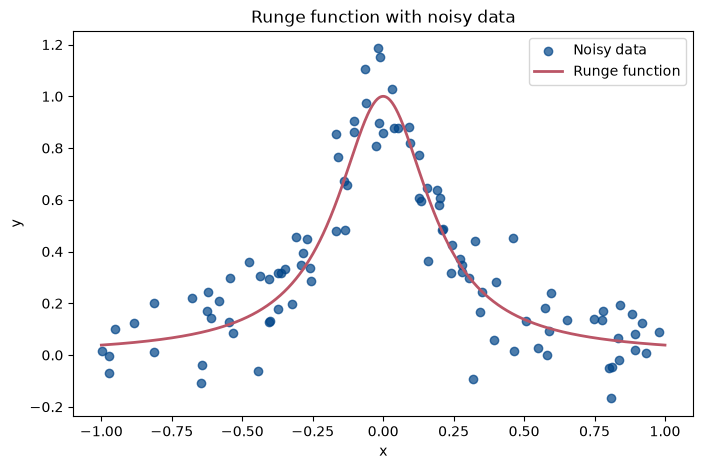

In [2]:
x , y= make_data(n= 100 , sigma= 0.1 , seed= 2026)
x_fine = np.linspace(-1,1, 1000)
y_fine = runge(x_fine)


plt.figure(figsize=(8,5))
plt.scatter(x,y, label= "Noisy data" , color= BLUE , alpha= 0.7)
plt.plot(x_fine , y_fine , label= "Runge function" , color= RED , linewidth= 2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge function with noisy data")
plt.legend()

plt.savefig("../results/a1_data.pdf", bbox_inches="tight")
plt.show()


## a.2 Train/test split and scaling

Split roughly 80/20. Then **centre `y` and standardise the feature columns —
fitting the scaler on the training data only**, and applying those same numbers to
the test data.

Why it matters: if the scaler sees the test set, information has leaked from test
into train and your error estimate is optimistically biased. The project asks for a
critical discussion of this, so write down what you did and why.

In [3]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2 , random_state= 2026)

print(len(x_test))
print(len(x_train))


20
80


## a.3 MSE and $R^2$ against polynomial degree

For degree $= 1 \ldots 15$: build the design matrix, fit OLS, record training and
test MSE and $R^2$.

Expect: training MSE falls monotonically; test MSE falls then rises. Use a log
scale on the MSE axis and mark the noise floor $\sigma^2$ with a grey dashed line —
no model can do better than that.

In [4]:
print(x_train.shape)
print(x_train.ndim)

(80,)
1


In [5]:

# x = raw input vector, X = polynomial design matrix
degrees = np.arange(1, 16)

#print(degrees)

mse_train= np.zeros(len(degrees))
mse_test= np.zeros(len(degrees))

r2_train= np.zeros(len(degrees))
r2_test= np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)
    X_test= polynomial_features(x_test, degree)

    X_mean= np.mean(X_train, axis=0)  #capital X
    X_std= np.std(X_train, axis=0)    #capital X

    X_train_scaled= (X_train - X_mean)/X_std
    X_test_scaled= (X_test - X_mean)/ X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta= ols(X_train_scaled, y_train_centered)

    y_train_pred = X_train_scaled @ theta + y_mean
    y_test_pred = X_test_scaled @ theta + y_mean


    mse_train[i]= MSE(y_train, y_train_pred)
    mse_test[i]= MSE(y_test, y_test_pred)

    r2_train[i]= R2(y_train, y_train_pred)
    r2_test[i]= R2(y_test, y_test_pred) 

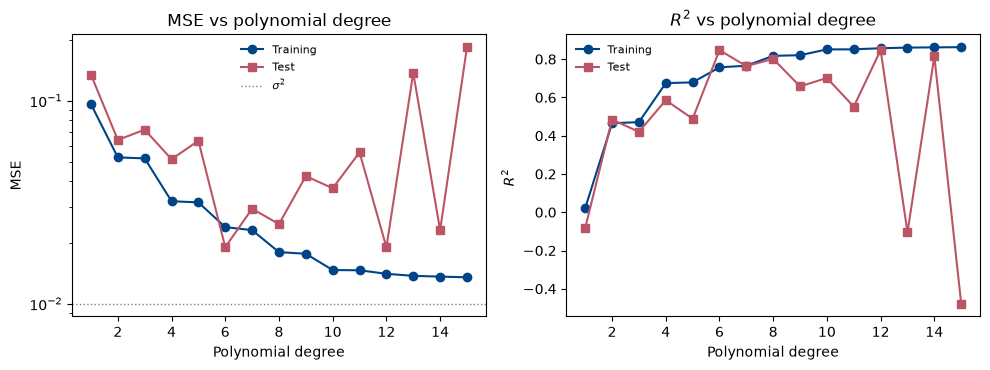

In [6]:
plt.figure(figsize=(10, 3.8))

#MSE plot
plt.subplot(1, 2, 1)

plt.plot(degrees, mse_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, mse_test, "s-",color=RED, label="Test")

plt.yscale("log")                                      # MSE panel only
plt.axhline(0.1**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("MSE vs polynomial degree")
plt.legend(frameon=False, fontsize=8)

#R2 plot
plt.subplot(1, 2, 2)

plt.plot(degrees, r2_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, r2_test,"s-", color=RED, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel( r"$R^2$ " )
plt.title( r"$R^2$ vs polynomial degree")
plt.legend(frameon=False, fontsize=8)


plt.tight_layout()
plt.savefig("../results/a3_mse_r2.pdf", bbox_inches="tight")
plt.show()


## a.4 The coefficients $\theta$ against degree

This is the figure that explains the U-shape. Plot the magnitude of the fitted
coefficients as the degree grows — expect them to reach enormous values with
alternating signs, because the design matrix becomes nearly singular and the fit
relies on huge cancelling terms.

A log scale on $|\theta_j|$ makes it readable.

In [7]:
 # a.4 — how the coefficients grow with degree

theta_all = []
max_theta = np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)

    X_mean= np.mean(X_train, axis=0)
    X_std = np.std(X_train, axis=0)

    X_train_scaled= (X_train - X_mean) / X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta = ols(X_train_scaled, y_train_centered)
    theta_all.append(theta)

    max_theta[i] = np.max(np.abs(theta))



In [8]:
#print(max_theta)
print(theta_all[5])

print(max_theta[5])

[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]
2.117857348560851


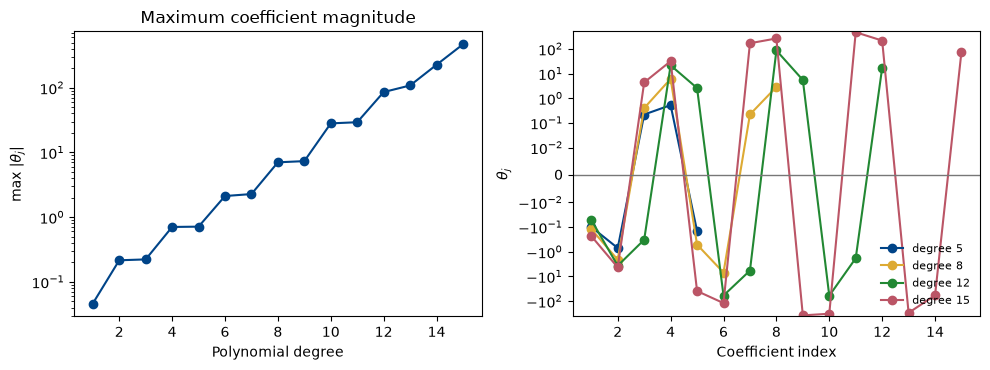

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))


##Left panel

axes[0].semilogy(degrees, max_theta, "o-", color=BLUE )

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel(r"max $|\theta_j|$")
axes[0].set_title("Maximum coefficient magnitude")


## Right panel
for degree, c in zip([5, 8, 12, 15], [BLUE, YELLOW, GREEN, RED]):
    theta = theta_all[degree - 1]
    j = np.arange(1, degree + 1)
    axes[1].plot(j, theta, "o-", color=c, label=f"degree {degree}")



axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel(r"$\theta_j$")
axes[1].legend(frameon= False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/a4_theta.pdf", bbox_inches="tight")
plt.show()




## a.5 Dependence on the number of points and the noise level

Repeat the degree sweep for a few values of $n$ and of $\sigma$.

Expect: more data supports a higher degree before overfitting sets in; more noise
pushes the optimal degree down.

In [10]:
# Different number of points
degrees = np.arange(1, 16)
n_values = [50, 100, 200, 1000]
sigma_fixed= 0.1

mse_by_n= {}


for n in n_values:

    #Generate new data set
    x_n , y_n = make_data(n=n, sigma=sigma_fixed, seed=2026)

    #split and test
    x_train_n, x_test_n, y_train_n , y_test_n = train_test_split(x_n, y_n, test_size= 0.2, random_state=2026)

     # One MSE value for each degree
    mse_test_n = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)

        mse_test_n[i] = MSE(y_test_n, y_test_pred)


    mse_by_n[n] = mse_test_n



In [11]:
sigma_values = [0.01, 0.1, 0.3]
n_fixed = 100

mse_by_sigma = {}

for sigma in sigma_values:
    #Generate new data set
    x_s , y_s = make_data(n=n_fixed, sigma=sigma, seed=2026)

    #split and test
    x_train_s, x_test_s, y_train_s , y_test_s = train_test_split(x_s, y_s, test_size= 0.2, random_state=2026)


    # Store test MSE for all degrees
    mse_test_s = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_s, x_test_s, y_train_s, degree)

        mse_test_s[i] = MSE(y_test_s, y_test_pred)


    mse_by_sigma[sigma] = mse_test_s

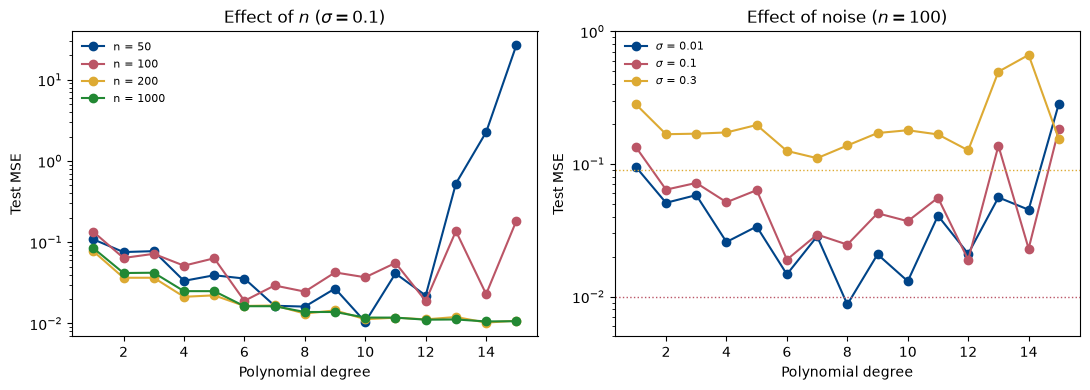

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = [BLUE, RED, YELLOW, GREEN]

  
# --------------------------------------------------
# Left panel: different n
# --------------------------------------------------

for i, n in enumerate(n_values):

      axes[0].semilogy(degrees, mse_by_n[n], "o-", color=colors[i], label=f"n = {n}")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Test MSE")
axes[0].set_title(r"Effect of $n$ ($\sigma=0.1$)")
axes[0].legend(frameon=False, fontsize=8)


# --------------------------------------------------
# Right panel: different sigma
# --------------------------------------------------

for i, sigma in enumerate(sigma_values):

    axes[1].semilogy(degrees, mse_by_sigma[sigma], "o-", color=colors[i], label=fr"$\sigma$ = {sigma}")
  
    axes[1].axhline(sigma**2, color=colors[i], linestyle=":", linewidth=1)
  
axes[1].set_ylim(5e-3, 1)
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("Test MSE")
axes[1].set_title(r"Effect of noise ($n=100$)")
axes[1].legend(frameon=False, fontsize=8)

 
plt.tight_layout()
plt.savefig("../results/a5_n_sigma.pdf", bbox_inches="tight")
plt.show()
  


---
# Part b) Ridge regression

**Goal:** control the explosion. Ridge minimises

$$C(\theta) = \frac{1}{n}\lVert X\theta - y \rVert^2 + \lambda\lVert\theta\rVert^2,
\qquad
\theta = (X^TX + n\lambda I)^{-1}X^Ty.$$

**The factor $n$ comes from the $1/n$ in the cost function — don't drop it.**

## b.1 Implement Ridge, and benchmark it

Add `ridge(X, y, lam)` to `regression.py`, then check it two ways:

1. `lam = 0` must reproduce your OLS result exactly
2. it must match `Ridge(alpha=n*lam, fit_intercept=False)` from scikit-learn

These benchmarks belong in the report — the course guidelines call validation
against known results *"extremely important"*.

In [13]:
import regression
import importlib
importlib.reload(regression)

from regression import ridge

In [14]:
from sklearn.linear_model import Ridge

In [15]:
# lambda = 0 must give OLS. Check at degree 6 and at degree 15.
for deg in [6, 15]:
    X_check = polynomial_features(x_train, deg)
    X_check = (X_check - X_check.mean(axis=0)) / X_check.std(axis=0)
    y_check = y_train - y_train.mean()

    diff = np.max(np.abs(ols(X_check, y_check) - ridge(X_check, y_check, 0)))
    print(f"degree {deg}: max |OLS - Ridge(lambda=0)| = {diff:.2e}, cond(X) = {np.linalg.cond(X_check):.2e}")


degree 6: max |OLS - Ridge(lambda=0)| = 5.20e-13, cond(X) = 4.57e+01
degree 15: max |OLS - Ridge(lambda=0)| = 5.24e-04, cond(X) = 1.85e+05


## b.1 Our Ridge vs scikit-learn Ridge

In [16]:
theta_ours = ridge( X_train_scaled, y_train_centered, lam = 0.01)

In [17]:
n= X_train_scaled.shape[0]

lam= 0.01
model_Ridge= Ridge(alpha= n*lam , fit_intercept= False)
model_Ridge.fit(X_train_scaled, y_train_centered)
theta_sklearn = model_Ridge.coef_

print("max |sklearnRidge - OurRidge| =", np.max(np.abs(theta_sklearn - theta_ours )))
print(np.allclose(theta_sklearn, theta_ours))

max |sklearnRidge - OurRidge| = 8.461981115814865e-15
True


## b.2 MSE against $\lambda$, at fixed degree

In [18]:
lambdas =np.logspace(-8, 2, 9)
print(lambdas)

[  0.       0.       0.       0.0001   0.001    0.0178   0.3162   5.6234
 100.    ]


In [19]:
degree= 15
mse_ridge= np.zeros(len(lambdas))
r2_ridge= np.zeros(len(lambdas))
theta_ridge_all= []

for i, lam in enumerate(lambdas):

   y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, degree, lam)


   mse_ridge[i]= MSE(y_test, y_test_pred)
   r2_ridge[i]= R2(y_test, y_test_pred)
   theta_ridge_all.append(theta)

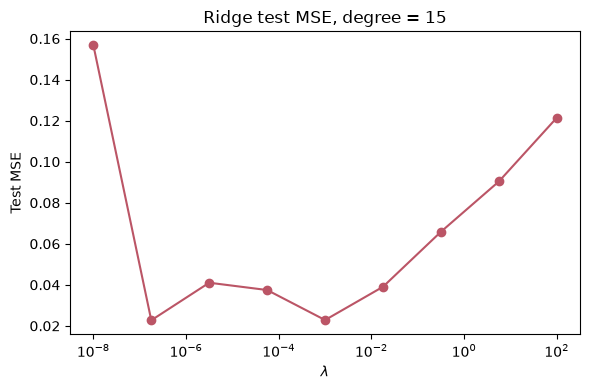

In [20]:
plt.figure(figsize=(6, 4))

plt.semilogx( lambdas,mse_ridge, "o-", color=RED)

plt.xlabel(r"$\lambda$")
plt.ylabel("Test MSE")
plt.title(f"Ridge test MSE, degree = {degree}")

plt.tight_layout()
plt.savefig("../results/b2_mse_lambda.pdf", bbox_inches="tight")
plt.show()

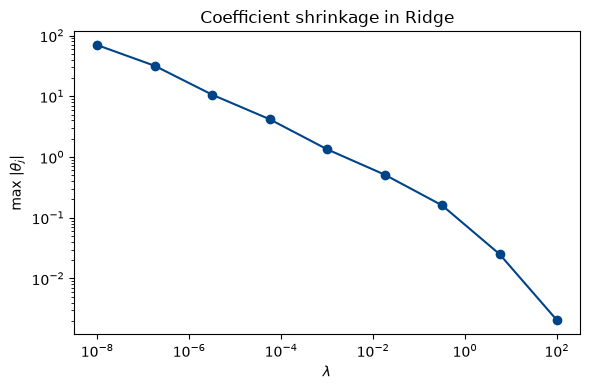

In [21]:
max_theta_ridge= np.zeros(len(lambdas))

for i, theta in enumerate(theta_ridge_all):
    max_theta_ridge[i]= np.max(np.abs(theta_ridge_all[i]))

plt.figure(figsize=(6, 4))
plt.loglog(lambdas, max_theta_ridge, "o-",color=BLUE
)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"max $|\theta_j|$")
plt.title("Coefficient shrinkage in Ridge")

plt.tight_layout()
plt.savefig("../results/b2_max_theta.pdf", bbox_inches="tight")
plt.show()


In [22]:
# comparing OLS and Ridge

y_train_pred_ols , y_test_pred_ols, theta_ols= fit_predict(x_train, x_test, y_train, degree, lam=0.0)

y_train_pred_ridge, y_test_pred_ridge, theta_ridge= fit_predict(x_train, x_test, y_train, degree, lam= 0.01)

print(f"OLS: MSE = {MSE(y_test, y_test_pred_ols)}, R2 = {R2(y_test, y_test_pred_ols)}")
print(f"Ridge: MSE = {MSE(y_test, y_test_pred_ridge)}, R2 = {R2(y_test, y_test_pred_ridge)}")

print("OLS max |theta|   :", np.max(np.abs(theta_ols)))
print("Ridge max |theta| :", np.max(np.abs(theta_ridge)))

OLS: MSE = 0.18336464981322653, R2 = -0.4777586683803623
Ridge: MSE = 0.03384974676893144, R2 = 0.7272006531181432
OLS max |theta|   : 469.2192091362218
Ridge max |theta| : 0.604640169415534


## b.3 MSE against degree, for several $\lambda$

In [23]:
lambdas_sweep = [0.0, 1e-6, 1e-4, 1e-2, 1.0]
mse_by_lambda = {}


for lam in lambdas_sweep:

    mse_deg= np.zeros(len(degrees))
    for i , deg in enumerate(degrees):
        y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, deg, lam=lam)
        mse_deg[i]= MSE(y_test, y_test_pred)

    mse_by_lambda[lam]= mse_deg



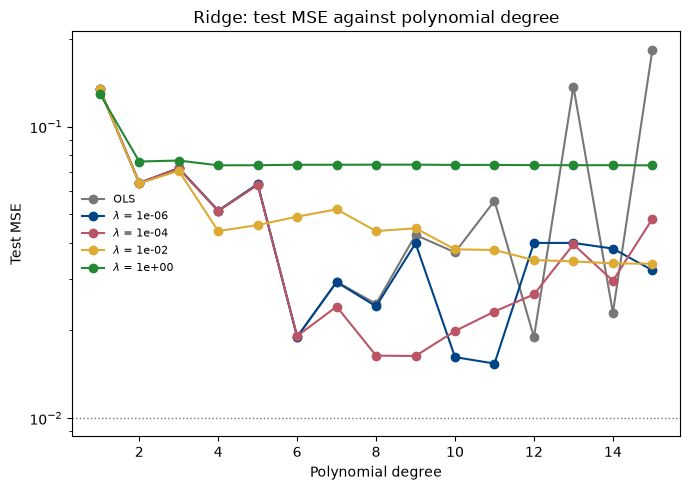

In [24]:
colors_b3 = [GREY, BLUE, RED, YELLOW, GREEN]
  
plt.figure(figsize=(7, 5))

for i, lam in enumerate(lambdas_sweep):
 
    label = "OLS" if lam == 0.0 else fr"$\lambda$ = {lam:.0e}"

    plt.semilogy(degrees, mse_by_lambda[lam], "o-", color=colors_b3[i], label=label)
  

plt.axhline(0.1**2, color=GREY, linestyle=":", linewidth=1)
  
plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Ridge: test MSE against polynomial degree")
plt.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/b3_mse_degree.pdf", bbox_inches="tight")
plt.show()

## b.4 Coefficient paths

Plot $\theta_j$ against $\lambda$ (log axis). Watch every coefficient shrink smoothly
toward zero — but **never reach it exactly**. That is the difference from Lasso in
part g).

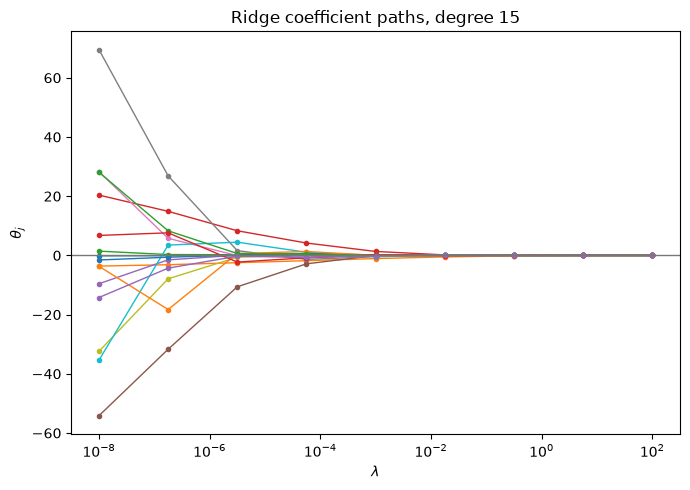

In [25]:
theta_paths = np.array(theta_ridge_all)

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas, theta_paths[:, j], "o-", linewidth=1, markersize=3)
 

plt.axhline(0, color=GREY, linewidth=1)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")
 
plt.tight_layout()
plt.savefig("../results/b4_coef_paths_9lambdas.pdf", bbox_inches="tight")
plt.show()
  


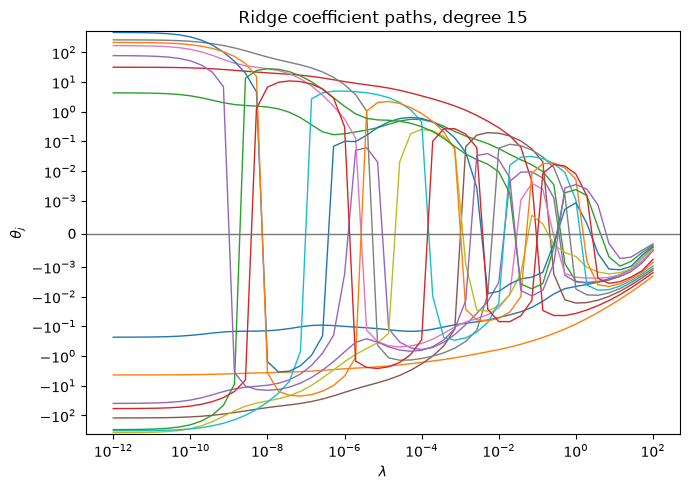

smallest |theta| at lam = 100: 0.0003029802222823351
any coefficient exactly zero: False


In [26]:
lambdas_paths = np.logspace(-12, 2, 50)

theta_paths = np.array([fit_predict(x_train, x_test, y_train, 15, lam=lam)[2]
                          for lam in lambdas_paths])

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas_paths, theta_paths[:, j], "-", linewidth=1)

plt.axhline(0, color=GREY, linewidth=1)
plt.yscale("symlog", linthresh=1e-3)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")

plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()

print("smallest |theta| at lam = 100:", np.min(np.abs(theta_paths[-1])))
print("any coefficient exactly zero:", np.any(theta_paths == 0))



## b.5 The SVD picture

With $X = U\Sigma V^T$, the two estimators differ only by a factor on each singular
direction:

| | coefficient on direction $j$ |
|---|---|
| OLS | $\dfrac{1}{\sigma_j}(u_j^Ty)$ |
| Ridge | $\dfrac{\sigma_j}{\sigma_j^2+\lambda}(u_j^Ty)$ |

so Ridge applies the shrinkage factor $\sigma_j^2/(\sigma_j^2+\lambda)$: directions with
large $\sigma_j$ pass through untouched, directions with small $\sigma_j$ are crushed.

Compute the singular values of your degree-15 design matrix, plot the shrinkage
factor for a few $\lambda$, and connect it to the coefficient explosion in a.4.

In [27]:
degree = 15

# Degree-15 design matrix
X_train = polynomial_features(x_train, degree)


X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std


singular_values = np.linalg.svd(X_train_scaled, compute_uv=False)

print("Singular values:")
print(singular_values)

print("\nLargest singular value :", singular_values[0])
print("Smallest singular value:", singular_values[-1])
print("Condition number       :", singular_values[0] / singular_values[-1])

Singular values:
[27.5911 18.0132  8.3101  5.9052  2.733   1.5002  0.705   0.3054  0.1289
  0.0461  0.0199  0.0053  0.0022  0.0004  0.0001]

Largest singular value : 27.591074964720235
Smallest singular value: 0.00014874894523645725
Condition number       : 185487.53351400484


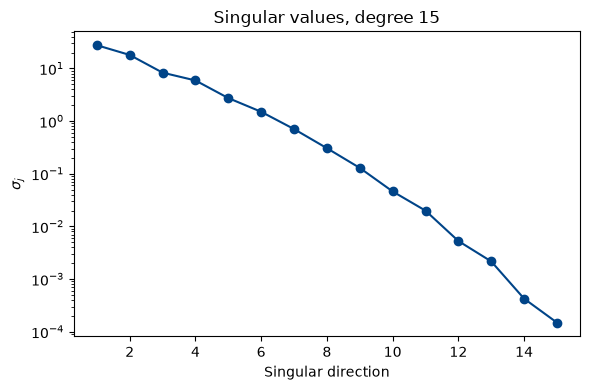

In [28]:
plt.figure(figsize=(6, 4))

plt.semilogy(
    np.arange(1, len(singular_values) + 1),
    singular_values,
    "o-",
    color=BLUE
)

plt.xlabel("Singular direction")
plt.ylabel(r"$\sigma_j$")
plt.title("Singular values, degree 15")
plt.savefig("../results/b5_singular_values.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

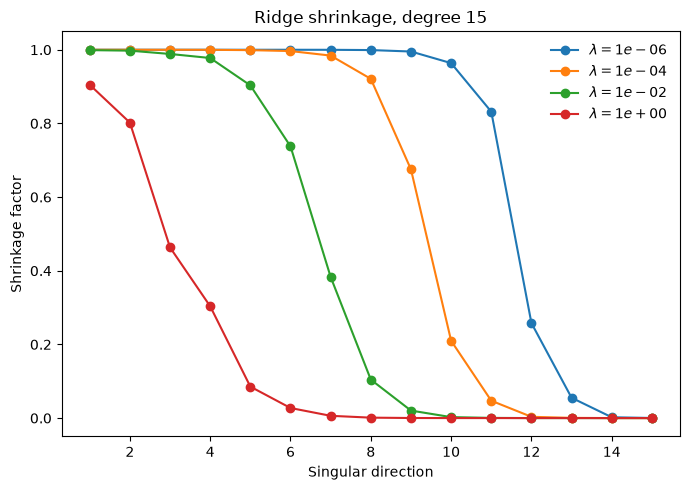

In [29]:
lambdas_svd = [1e-6, 1e-4, 1e-2, 1.0]

n_train = X_train_scaled.shape[0]

plt.figure(figsize=(7, 5))

for lam in lambdas_svd:

    shrinkage = singular_values**2 / (
        singular_values**2 + n_train * lam
    )

    plt.plot(
        np.arange(1, len(singular_values) + 1),
        shrinkage,
        "o-",
        label=fr"$\lambda={lam:.0e}$"
    )

plt.xlabel("Singular direction")
plt.ylabel("Shrinkage factor")
plt.title("Ridge shrinkage, degree 15")
plt.ylim(-0.05, 1.05)
plt.legend(frameon=False)
plt.savefig("../results/b5_shrinkage.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [30]:
print("\nShrinkage of smallest singular direction:")

for lam in lambdas_svd:

    shrinkage = singular_values**2 / (
        singular_values**2 + n_train * lam
    )

    print(
        f"lambda = {lam:.0e}  "
        f"largest direction = {shrinkage[0]:.6f}  "
        f"smallest direction = {shrinkage[-1]:.6e}"
    )


Shrinkage of smallest singular direction:
lambda = 1e-06  largest direction = 1.000000  smallest direction = 2.765016e-04
lambda = 1e-04  largest direction = 0.999989  smallest direction = 2.765773e-06
lambda = 1e-02  largest direction = 0.998950  smallest direction = 2.765781e-08
lambda = 1e+00  largest direction = 0.904905  smallest direction = 2.765781e-10


---
# Part c) Bias-variance tradeoff and the bootstrap

## c.1 Train/test MSE against complexity

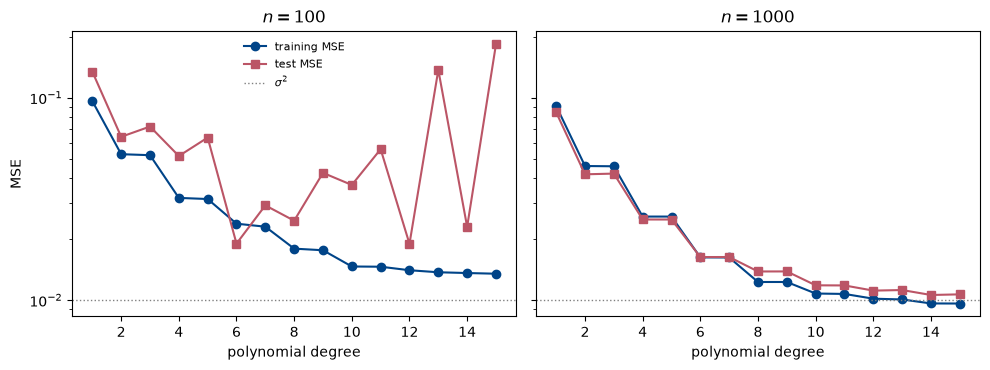

In [31]:
degrees_c = np.arange(1, 16)
sigma = 0.1

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

for ax, n in zip(axes, (100, 1000)):
    x_n, y_n = make_data(n=n, sigma=sigma, seed=2026)
    x_tr, x_te, y_tr, y_te = train_test_split(x_n, y_n, test_size=0.2, random_state=2026)

    mse_train = np.zeros(len(degrees_c))
    mse_test = np.zeros(len(degrees_c))

    for i, degree in enumerate(degrees_c):
        y_train_pred, y_test_pred, theta = fit_predict(x_tr, x_te, y_tr, degree)
        mse_train[i] = MSE(y_tr, y_train_pred)
        mse_test[i] = MSE(y_te, y_test_pred)

    ax.plot(degrees_c, mse_train, "o-", color=BLUE, label="training MSE")
    ax.plot(degrees_c, mse_test, "s-", color=RED, label="test MSE")
    ax.axhline(sigma**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
    ax.set_yscale("log")
    ax.set_xlabel("polynomial degree")
    ax.set_title(f"$n = {n}$")

axes[0].set_ylabel("MSE")
axes[0].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/c1_train_test_mse.pdf", bbox_inches="tight")
plt.show()

## c.2 Bootstrap: bias-variance against degree

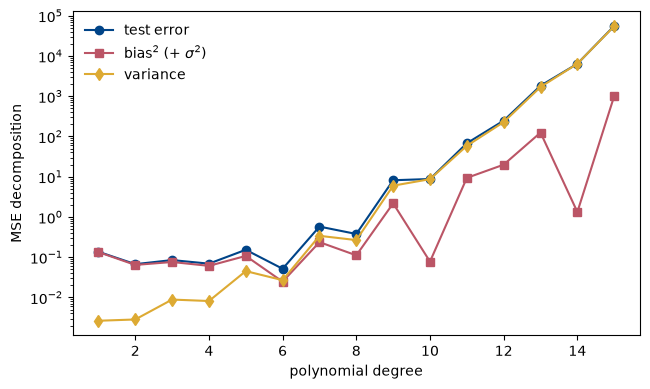

In [32]:
from sklearn.utils import resample


def bias_variance_sweep(n=100, sigma=0.1, degrees=degrees_c, n_bootstraps=100, seed=2026):
    x, y = make_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
    y_test_col = y_test.reshape(-1, 1)

    error, bias, variance = (np.zeros(len(degrees)) for _ in range(3))

    for i, degree in enumerate(degrees):
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for b in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train, random_state=seed + b)
            y_pred[:, b] = fit_predict(x_, x_test, y_, degree)[1]

        error[i] = np.mean(np.mean((y_test_col - y_pred)**2, axis=1, keepdims=True))
        bias[i] = np.mean((y_test_col - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[i] = np.mean(np.var(y_pred, axis=1, keepdims=True))

    return error, bias, variance


error, bias, variance = bias_variance_sweep(n=100)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(degrees_c, error, "o-", color=BLUE, label="test error")
ax.plot(degrees_c, bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(degrees_c, variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("../results/c2_bias_variance.pdf", bbox_inches="tight")
plt.show()

## c.3 Dependence on the number of data points

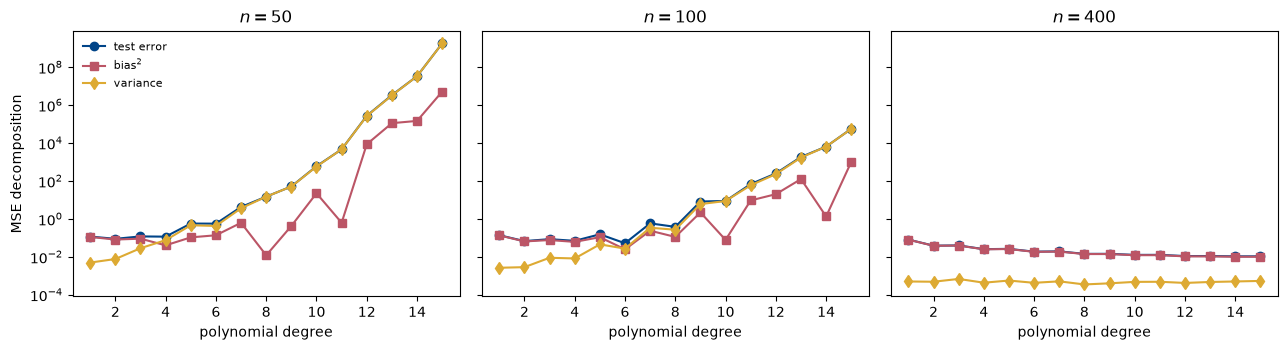

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)

for ax, n in zip(axes, (50, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n)

    ax.plot(degrees_c, err, "o-", color=BLUE, label="test error")
    ax.plot(degrees_c, b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(degrees_c, var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_xlabel("polynomial degree")
    ax.set_title(f"$n = {n}$")

axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/c3_bias_variance_n.pdf", bbox_inches="tight")
plt.show()

---
# Part d) Cross-validation

# Goal

Use K-fold cross-validation of sklearn and evaluate against MSE test results for OLS from a) and c), as a function of polynomoial degree, and for for Ridge as a function of both polynomial degree and lambda. Use k =5, and k = 10.

Compare the results from cross-val with the one we got from bootstrap in c)


## d.1 
Setup K-fold and cross validation, and compute OLS MSE against degrees. (same as in a) and c), but for CV )

k=5: CV selects degree 12 (CV-MSE 0.0234)
k=10: CV selects degree 10 (CV-MSE 0.0251)


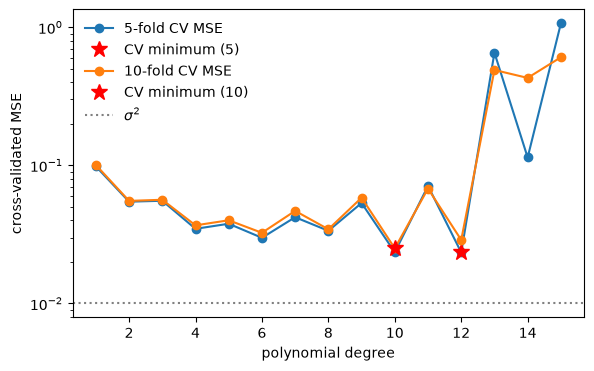

In [34]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler



n_d1 = 100

x_n,y_n = x_train, y_train

k_list = [5,10]
mse_cv = {}
X = x_n.reshape(-1,1)


for k in k_list:
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    mse_cv[k] = []

    for deg in degrees:
        model = make_pipeline(PolynomialFeatures(degree=deg, include_bias = False), StandardScaler(), LinearRegression(fit_intercept = True))
        scores = -cross_val_score(model, X, y_n, scoring = "neg_mean_squared_error" , cv = kfold)

        mse_cv[k].append(scores.mean())


fig, ax = plt.subplots(figsize=(6.6, 4.0))

for k in k_list:
    idx = np.argmin(mse_cv[k])
    best_deg = degrees[idx]
    print(f"k={k}: CV selects degree {best_deg} (CV-MSE {mse_cv[k][idx]:.4f})")

    ax.plot(degrees, mse_cv[k], "o-", label=f"{k}-fold CV MSE")
    ax.plot(best_deg, mse_cv[k][idx], "*", color="red", ms=12, label=f"CV minimum ({k})")

ax.axhline(0.1**2, color = "gray", linestyle = ":", label = r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.savefig("../results/d1_cv_ols.pdf", bbox_inches="tight")
plt.show()



Notes to the report:

**Structure**

- n = 100, sigma = 0.1, degrees = 1-15, k = 5 and k = 10, KFold(shuffle=True, random_state=2026)
- Pipeline: PolynomialFeatures(include_bias = False) #setting up the design_matrix without intercept --> StandardScaler() #every scaling is inside each fold, only training data
--> LinearRegression(fit_intercept = True) #because y is not centered in the training data, StandardScaler only scales X.
- cross_val_score, with scorinng "neg_mean_squared_error" --> take the negativ of this to get the MSE we want. Save these scores as the mean over each fold.

**Results**

- k = 5: Degree = 12, CV MSE = 0.202
- k = 10, Degree = 10, CV MSE = 0.0173
- For degree 1-3, the model is to simple --> high bias
- degree 13-15, high increase in MSE, most likely the variance ( think about result in c) )
- Seems to be a correlation between odd-numbered polynomials and a higher MSE, look at degrees: 9,11,13,15. (clearly for k = 5 )
- k = 5, and k = 10 are similar for low degrees --> at higher degrees they spread
- Everything is above the noise floor

**Questions for report**

- Why do the number of folds differ the most at higher degrees?? (number of training points? )
- What is the odd-numbered polynomial cause ?
- Can we see the bias-variance trade off?





## d.2
Doing a similar analysis as in d.1, but now we are going to use Ridge instead.

k=5: CV selects degree 11 (CV-MSE 0.0175), Best lmbda: 6.58e-07
k=10: CV selects degree 10 (CV-MSE 0.0189), Best lmbda: 6.58e-07


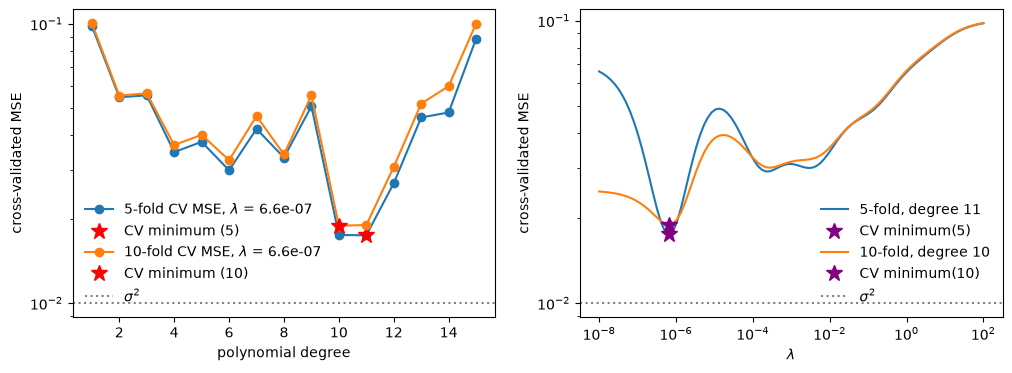

In [35]:
nlambdas = 100
lambdas = np.logspace(-8, 2, nlambdas)
ridge_cv = {}

N = len(X) 

for k in k_list:
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    ridge_cv[k] = []
    n_fold = N * (k -1) // k

    for deg in degrees:
        for lmb in lambdas:
            model = make_pipeline(PolynomialFeatures(degree=deg, include_bias = False),StandardScaler(), Ridge(alpha=n_fold*lmb))
            scores = -cross_val_score(model, X, y_n, scoring = "neg_mean_squared_error" , cv = kfold)

            ridge_cv[k].append(scores.mean())




fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 4.0))
for k in k_list:
    ridge_cv[k] = np.array(ridge_cv[k]).reshape(len(degrees), nlambdas)

    i, j = np.unravel_index(np.argmin(ridge_cv[k]), ridge_cv[k].shape)
    best_deg = degrees[i]
    best_lmb = lambdas[j]
    best_mse = ridge_cv[k][i,j]

    print(f"k={k}: CV selects degree {best_deg} (CV-MSE {best_mse:.4f}), Best lmbda: {best_lmb:.2e}")
    
    ax1.plot(degrees, ridge_cv[k][:,j], "o-", label=f"{k}-fold CV MSE, $\\lambda$ = {best_lmb:.2}")
    ax1.plot(best_deg, best_mse, "*", color="red", ms=12, label=f"CV minimum ({k})")
    ax2.plot(lambdas, ridge_cv[k][i,:], "-", label=f"{k}-fold, degree {best_deg}")
    ax2.plot(best_lmb,best_mse, "*", color="purple", ms=12, label=f"CV minimum({k})")

ax1.axhline(0.1**2, color = "gray", linestyle = ":", label = r"$\sigma^2$")
ax2.axhline(0.1**2, color = "gray", linestyle = ":", label = r"$\sigma^2$")
ax1.set_yscale("log")
ax1.set_xlabel("polynomial degree")
ax1.set_ylabel("cross-validated MSE")
ax1.legend(frameon=False)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel("cross-validated MSE")
ax2.legend(frameon = False)
plt.savefig("../results/d2_cv_ridge.pdf", bbox_inches="tight")
plt.show()



    

Notes to the report

**Structure**
- n = 100, degrees: 1-15, noise = 0.1, lambda = logspace(-8,2,100), k = 5 and 10.
- Pipeline: PolynomialFeatures(include_bias = False) #setting up the design_matrix without intercept --> StandardScaler() #every scaling is inside each fold, only training data
--> Ridge (alpha = n_fold * lambda) # n_fold = N(k-1) /k , (80 for k = 5, 90 for k = 10 ), n_fold comes from the 1/n factor infront of the error term in the cost function (sklearn does not have this so we add it through alpha )
- Left figure is: MSE against degree for a set lmbda (best lmbda for each k )
- Right figure is: MSE against lmbda at a set degre (best degree for each k)

**Results**

- k = 5: degree 11, CV-MSE = 0.0178, lmbda = 1.32e-6
- k = 10, degree 10, CV-MSE = 0.0176, lmbda = 8.30e-7
- For lmbda ≥ 1e-3, the k=5, and k=10 are identical. They grow to the MSE of the 1st degree polynomial.
- k = 5, has a clear dump for lmbda = 1e-6, While k=10 is smooth for smallest lambda values.
- oddnumber spikes for MSE against degree still.
- We get a rise in MSE for lmda : 1e-5 - 1e-4
- above noise floor

**Questions for report**

- Why does k = 5 have a clear dip in compared to k = 10 ?
- What is this rise in MSE for lmbda 1e-5 - 1e-4 ??


## d3  Cross-val vs bootstrap

Compare cross-val from d1) to the bootstrap from c), OLS for both same data. So the difference in result comes from the resampling only.

1) do the methods point to the same complexity?
2) Answer why scaling needs to happen inside the loop for cross-val, (this is to prevent data leakage, by doing it inside the fold we have already seperated the training and test data)

Bootstrap: selectes degree 6, MSE: 0.0517
5-fold: selectes degree 12, MSE: 0.0234
10-fold: selectes degree 10, MSE: 0.0251


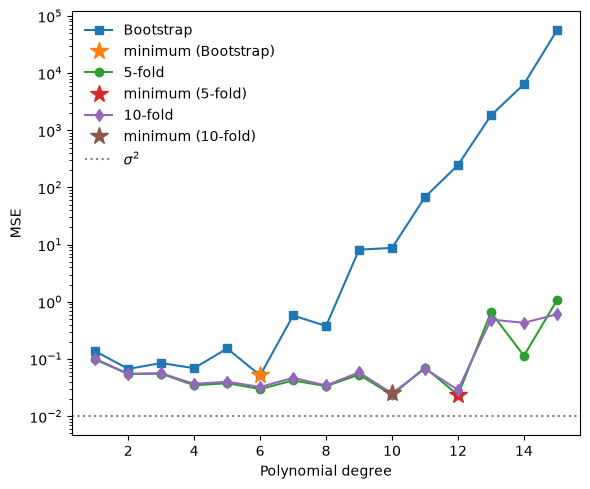

In [36]:
#setting up bootstrap from c3 with the same values as CV from d1

n_d3 = 100
x_d3, y_d3 = x_n, y_n
X = x_d3.reshape(-1,1)
# same data as x_d3, y_d3: make_data(n=100, sigma=0.1, seed=2026) inside the sweep
err_boot, b2_boot, var_boot = bias_variance_sweep(n=n_d3, sigma=0.1, degrees=degrees, n_bootstraps=100, seed=2026)

curves = {"Bootstrap": np.array(err_boot),
          "5-fold": np.array(mse_cv[5]),
          "10-fold": np.array(mse_cv[10])
}

marks = {"Bootstrap": "s-", "5-fold": "o-", "10-fold": "d-"}


fig, ax = plt.subplots(figsize = (6.0, 5.0))

for name, mse in curves.items():
    idx = np.argmin(mse)
    print(f"{name}: selectes degree {degrees[idx]}, MSE: {mse[idx]:.4f}")

    ax.plot(degrees, mse, marks[name], label = name)
    ax.plot(degrees[idx], mse[idx], "*", ms = 13, label=f"minimum ({name})")

ax.axhline(0.1**2, color="gray", linestyle=":", label=r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.legend(frameon = False)
plt.tight_layout()
plt.savefig("../results/d3_cv_vs_bootstrap.pdf", bbox_inches="tight")
plt.show()
    





**Structure**

- Same data for both from: make_data(n=100, sigma = 0.1, seed = 2026), OLS from degrees 1-15
- Bootstrap, same as from c2, 100 bootstrap samples of the training set.
- CV, same as from d1, with k = 5 and k = 10

**Bugs found and fixed**
- resample() had no random_state → new bootstrap samples every run, not reproducible
  - same code gave best degree 6 in c3 and 2 in d3; n=400 gave 14 or 15
- random_state=2026 made all 100 samples identical (no bootstrap, variance = 0)
- Fix: random_state = seed + i → different samples per round, identical between runs
- c2, c3, d1, d3 rerun after the fix

**Results**
- Bootstrap: degree 6, MSE:  0.0517
- 5 fold: degree 12, MSE : 0.0202
- 10 fold: degree 12, MSE : 0.0173
- For degrees 1-6. The methods nearly agree, with bootstrap having the highest MSE.
- For degrees ≥ 7: We get bootstrap explotion, while CV stays low and reaches minimum at degree 12.
- The models do not point to the same complexity.

**questions for report**

- Why is CV more stable ??
- Why must scaling be done inside each fold ?
- What causes the bootstrap explotion




---
# Part e) Gradient descent, analytical and automatic gradients

## e.1 The analytical gradient

In [37]:

degree_e = 6

X_train_e = polynomial_features(x_train, degree_e)
X_test_e = polynomial_features(x_test, degree_e)


X_mean_e = X_train_e.mean(axis=0)
X_std_e = X_train_e.std(axis=0)

X_train_e = (X_train_e - X_mean_e) / X_std_e
X_test_e = (X_test_e - X_mean_e) / X_std_e

# Centre target using training mean
y_mean_e = y_train.mean()
y_train_e = y_train - y_mean_e


def gradient_ols(theta, X, y):
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y)


def gradient_ridge(theta, X, y, lam):
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

In [38]:
theta_test = np.zeros(degree_e)

g_ols = gradient_ols(theta_test, X_train_e, y_train_e)
g_ridge = gradient_ridge(
    theta_test,
    X_train_e,
    y_train_e,
    lam=0.01
)

print("OLS gradient shape:  ", g_ols.shape)
print("Ridge gradient shape:", g_ridge.shape)

print("OLS gradient:")
print(g_ols)

print("\nRidge gradient:")
print(g_ridge)

OLS gradient shape:   (6,)
Ridge gradient shape: (6,)
OLS gradient:
[0.0923 0.4272 0.1109 0.3302 0.1131 0.2767]

Ridge gradient:
[0.0923 0.4272 0.1109 0.3302 0.1131 0.2767]


In [39]:
theta_test = np.ones(degree_e)

g_ols = gradient_ols(theta_test, X_train_e, y_train_e)
g_ridge = gradient_ridge(
    theta_test,
    X_train_e,
    y_train_e,
    lam=0.01
)

print("OLS gradient:")
print(g_ols)

print("\nRidge gradient:")
print(g_ridge)

print("\nRidge - OLS:")
print(g_ridge - g_ols)

OLS gradient:
[7.1037 7.9856 8.0014 8.2907 7.9211 8.1315]

Ridge gradient:
[7.1237 8.0056 8.0214 8.3107 7.9411 8.1515]

Ridge - OLS:
[0.02 0.02 0.02 0.02 0.02 0.02]


## e.2 Automatic differentiation with JAX

In [40]:
import jax
import jax.numpy as jnp


jax.config.update("jax_enable_x64", True)


def cost_ols_jax(theta, X, y):
    return jnp.mean((X @ theta - y)**2)


# Ridge cost
def cost_ridge_jax(theta, X, y, lam):
    return jnp.mean((X @ theta - y)**2) + lam * jnp.sum(theta**2)


gradient_ols_ad = jax.grad(cost_ols_jax, argnums=0)

gradient_ridge_ad = jax.grad(cost_ridge_jax, argnums=0)

In [41]:

Xj = jnp.asarray(X_train_e)
yj = jnp.asarray(y_train_e)


theta_check = np.linspace(
    0.1,
    1.0,
    X_train_e.shape[1]
)

lam_check = 0.01


# ---------- OLS ----------

g_ols_analytic = gradient_ols(
    theta_check,
    X_train_e,
    y_train_e
)

g_ols_ad = gradient_ols_ad(
    jnp.asarray(theta_check),
    Xj,
    yj
)


# ---------- Ridge ----------

g_ridge_analytic = gradient_ridge(
    theta_check,
    X_train_e,
    y_train_e,
    lam_check
)

g_ridge_ad = gradient_ridge_ad(
    jnp.asarray(theta_check),
    Xj,
    yj,
    lam_check
)


print(
    "OLS max |analytic - AD| =",
    np.max(np.abs(g_ols_analytic - np.asarray(g_ols_ad)))
)

print(
    "Ridge max |analytic - AD| =",
    np.max(np.abs(g_ridge_analytic - np.asarray(g_ridge_ad)))
)

OLS max |analytic - AD| = 1.7763568394002505e-15
Ridge max |analytic - AD| = 1.7763568394002505e-15


## e.3 Plain gradient descent for OLS

In [42]:
theta_ols_closed = ols(
    X_train_e,
    y_train_e
)

print("Closed-form theta:")
print(theta_ols_closed)

Closed-form theta:
[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]


In [43]:
def gradient_descent(theta0, gradient_function, eta,
                     max_iter=20000, tol=1e-10):

    theta = theta0.copy()

    cost_history = []

    for k in range(max_iter):

       
        gradient = np.asarray(
            gradient_function(theta)
        )

      
        theta = theta - eta * gradient

      
        cost = np.mean(
            (X_train_e @ theta - y_train_e)**2
        )

        cost_history.append(cost)

        
        if np.linalg.norm(gradient) < tol:
            break

    return theta, np.array(cost_history), k + 1

In [44]:
n_train = len(y_train_e)

H_ols = (
    2.0 / n_train
) * X_train_e.T @ X_train_e

lambda_max = np.linalg.eigvalsh(H_ols).max()

eta_max = 2.0 / lambda_max


eta = 0.5 * eta_max

print("lambda_max =", lambda_max)
print("eta_max     =", eta_max)
print("eta used    =", eta)

lambda_max = 7.696475114645237
eta_max     = 0.2598592173960649
eta used    = 0.12992960869803244


In [45]:
# Initial parameters
theta0 = np.zeros(X_train_e.shape[1])


# Analytical gradient function for the current training data
def ols_gradient_analytic(theta):
    return gradient_ols(
        theta,
        X_train_e,
        y_train_e
    )


# Run gradient descent
theta_gd_analytic, cost_analytic, n_iter_analytic = gradient_descent(
    theta0=theta0,
    gradient_function=ols_gradient_analytic,
    eta=eta,
    max_iter=20000,
    tol=1e-10
)


print("Analytical-gradient GD finished.")
print("Number of iterations:", n_iter_analytic)
print("Theta:")
print(theta_gd_analytic)

Analytical-gradient GD finished.
Number of iterations: 20000
Theta:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]


In [46]:

Xj = jnp.asarray(X_train_e)
yj = jnp.asarray(y_train_e)


def ols_gradient_ad(theta):

    theta_jax = jnp.asarray(theta)

    g = gradient_ols_ad(
        theta_jax,
        Xj,
        yj
    )

    
    return np.asarray(g)


theta_gd_ad, cost_ad, n_iter_ad = gradient_descent(
    theta0=theta0,
    gradient_function=ols_gradient_ad,
    eta=eta,
    max_iter=20000,
    tol=1e-10
)


print("\nJAX-gradient GD finished.")
print("Number of iterations:", n_iter_ad)
print("Theta:")
print(theta_gd_ad)


JAX-gradient GD finished.
Number of iterations: 20000
Theta:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]


In [47]:

theta_ols_closed = ols(
    X_train_e,
    y_train_e
)


theta_ols_closed = np.asarray(theta_ols_closed).ravel()
theta_gd_analytic = np.asarray(theta_gd_analytic).ravel()
theta_gd_ad = np.asarray(theta_gd_ad).ravel()


error_analytic = np.linalg.norm(
    theta_gd_analytic - theta_ols_closed
)

error_ad = np.linalg.norm(
    theta_gd_ad - theta_ols_closed
)

error_between_gd = np.linalg.norm(
    theta_gd_analytic - theta_gd_ad
)


print("\n--------------------------------------")
print("Comparison with closed-form OLS")
print("--------------------------------------")

print("Closed-form theta:")
print(theta_ols_closed)

print("\nGD theta — analytical gradient:")
print(theta_gd_analytic)

print("\nGD theta — JAX gradient:")
print(theta_gd_ad)

print("\nIterations:")
print("Analytical gradient:", n_iter_analytic)
print("JAX gradient       :", n_iter_ad)

print("\nParameter errors:")
print(
    "||theta_GD analytical - theta_closed|| =",
    error_analytic
)

print(
    "||theta_GD JAX - theta_closed||        =",
    error_ad
)

print(
    "||theta_GD analytical - theta_GD JAX|| =",
    error_between_gd
)


--------------------------------------
Comparison with closed-form OLS
--------------------------------------
Closed-form theta:
[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]

GD theta — analytical gradient:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]

GD theta — JAX gradient:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]

Iterations:
Analytical gradient: 20000
JAX gradient       : 20000

Parameter errors:
||theta_GD analytical - theta_closed|| = 0.00018120458648055444
||theta_GD JAX - theta_closed||        = 0.00018120458648226582
||theta_GD analytical - theta_GD JAX|| = 1.7596629984427639e-15


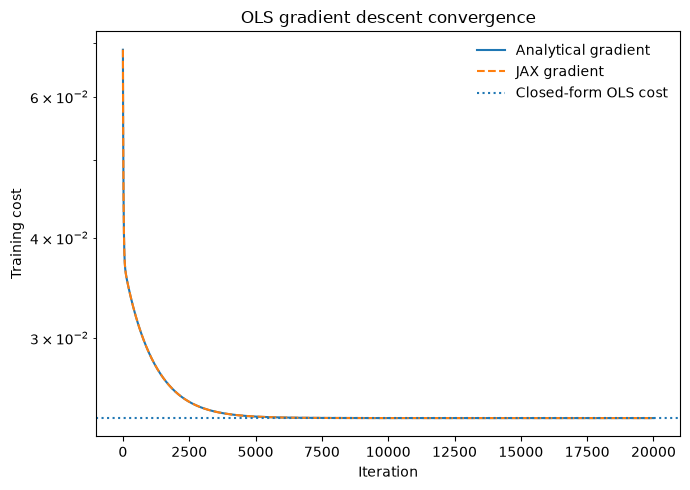

In [48]:


closed_cost = np.mean(
    (X_train_e @ theta_ols_closed - y_train_e)**2
)


plt.figure(figsize=(7, 5))

plt.semilogy(
    np.arange(1, len(cost_analytic) + 1),
    cost_analytic,
    label="Analytical gradient"
)

plt.semilogy(
    np.arange(1, len(cost_ad) + 1),
    cost_ad,
    "--",
    label="JAX gradient"
)

plt.axhline(
    closed_cost,
    linestyle=":",
    label="Closed-form OLS cost"
)

plt.xlabel("Iteration")
plt.ylabel("Training cost")
plt.title("OLS gradient descent convergence")
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("../results/e3_gd_convergence.pdf", bbox_inches="tight")
plt.show()

In [49]:
x_plot = np.linspace(-1, 1, 500)

X_plot = polynomial_features(
    x_plot,
    degree_e
)


X_plot_e = (
    X_plot - X_mean_e
) / X_std_e

In [50]:

y_plot_closed = (
    X_plot_e @ theta_ols_closed
    + y_mean_e
)

# GD with analytical gradient
y_plot_gd_analytic = (
    X_plot_e @ theta_gd_analytic
    + y_mean_e
)

# GD with JAX gradient
y_plot_gd_ad = (
    X_plot_e @ theta_gd_ad
    + y_mean_e
)

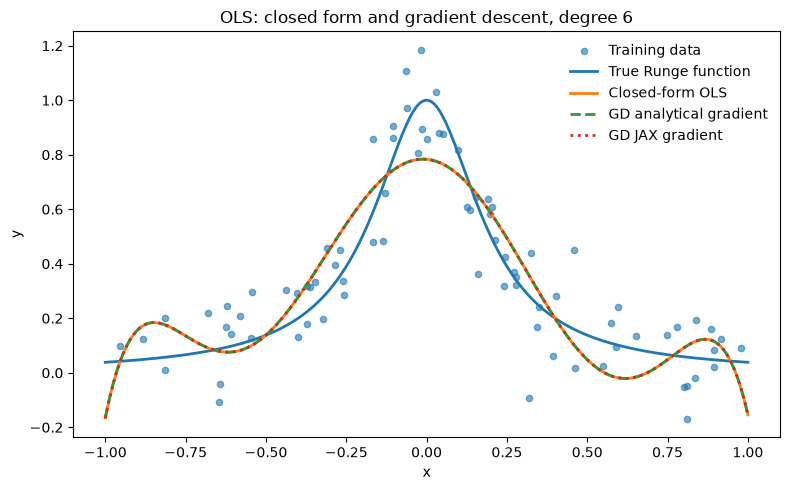

In [51]:
plt.figure(figsize=(8, 5))

plt.scatter(
    x_train,
    y_train,
    s=20,
    alpha=0.6,
    label="Training data"
)

plt.plot(
    x_plot,
    runge(x_plot),
    linewidth=2,
    label="True Runge function"
)

plt.plot(
    x_plot,
    y_plot_closed,
    linewidth=2,
    label="Closed-form OLS"
)

plt.plot(
    x_plot,
    y_plot_gd_analytic,
    "--",
    linewidth=2,
    label="GD analytical gradient"
)

plt.plot(
    x_plot,
    y_plot_gd_ad,
    ":",
    linewidth=2,
    label="GD JAX gradient"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"OLS: closed form and gradient descent, degree {degree_e}")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e3_gd_fit.pdf", bbox_inches="tight")
plt.show()

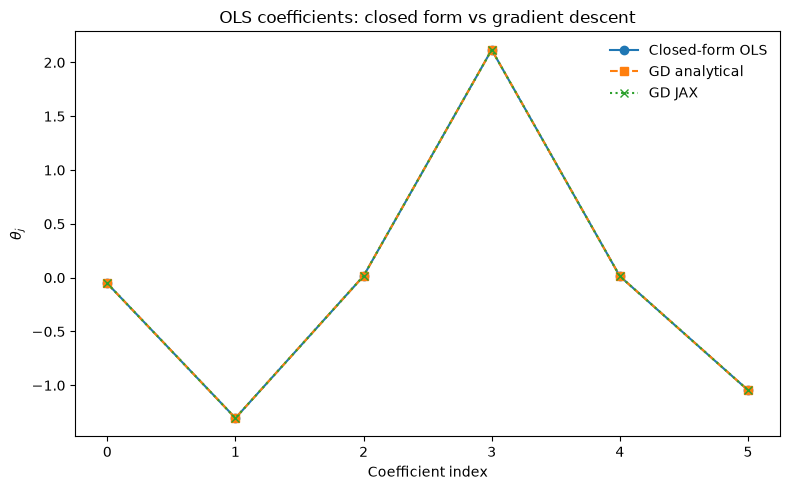

In [52]:


j = np.arange(len(theta_ols_closed))

plt.figure(figsize=(8, 5))

plt.plot(
    j,
    theta_ols_closed,
    "o-",
    label="Closed-form OLS"
)

plt.plot(
    j,
    theta_gd_analytic,
    "s--",
    label="GD analytical"
)

plt.plot(
    j,
    theta_gd_ad,
    "x:",
    label="GD JAX"
)

plt.xlabel("Coefficient index")
plt.ylabel(r"$\theta_j$")
plt.title("OLS coefficients: closed form vs gradient descent")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e3_gd_coefficients.pdf", bbox_inches="tight")
plt.show()

In [53]:

y_train_pred_closed = (
    X_train_e @ theta_ols_closed
    + y_mean_e
)

y_test_pred_closed = (
    X_test_e @ theta_ols_closed
    + y_mean_e
)

y_train_pred_gd = (
    X_train_e @ theta_gd_analytic
    + y_mean_e
)

y_test_pred_gd = (
    X_test_e @ theta_gd_analytic
    + y_mean_e
)

## e.4 The learning rate and the largest Hessian eigenvalue

In [54]:
theta_ols_closed = np.asarray(
    ols(X_train_e, y_train_e)
).ravel()

n_train = len(y_train_e)


H_ols = (2.0 / n_train) * X_train_e.T @ X_train_e


eigenvalues_ols = np.linalg.eigvalsh(H_ols)

lambda_min = eigenvalues_ols.min()
lambda_max = eigenvalues_ols.max()


eta_max = 2.0 / lambda_max

print("Smallest Hessian eigenvalue =", lambda_min)
print("Largest Hessian eigenvalue  =", lambda_max)
print("Condition number            =", lambda_max / lambda_min)
print("Theoretical eta_max         =", eta_max)

Smallest Hessian eigenvalue = 0.0036826177851674545
Largest Hessian eigenvalue  = 7.696475114645237
Condition number            = 2089.9467616879674
Theoretical eta_max         = 0.2598592173960649


In [55]:

eta_factors = [0.25, 0.75, 0.99, 1.01]

etas = [factor * eta_max for factor in eta_factors]

for factor, eta_value in zip(eta_factors, etas):
    print(
        f"{factor:.2f} eta_max = {eta_value:.6e}"
    )

0.25 eta_max = 6.496480e-02
0.75 eta_max = 1.948944e-01
0.99 eta_max = 2.572606e-01
1.01 eta_max = 2.624578e-01


In [56]:
def run_ols_with_eta(eta, max_iter=3000):

    theta = np.zeros_like(theta_ols_closed)

    cost_history = []

    for k in range(max_iter):

       
        g = gradient_ols(
            theta,
            X_train_e,
            y_train_e
        )

      
        theta = theta - eta * g

        cost = np.mean(
            (X_train_e @ theta - y_train_e)**2
        )

        cost_history.append(cost)

     
        if (not np.isfinite(cost)) or cost > 1e10:
            break

    return theta, np.array(cost_history)

In [57]:
eta_results = {}

for factor, eta_value in zip(eta_factors, etas):

    theta_eta, cost_eta = run_ols_with_eta(
        eta_value,
        max_iter=3000
    )

    eta_results[factor] = {
        "eta": eta_value,
        "theta": theta_eta,
        "cost": cost_eta
    }

In [58]:
closed_cost_ols = np.mean(
    (X_train_e @ theta_ols_closed - y_train_e)**2
)

print("Closed-form OLS cost =", closed_cost_ols)

Closed-form OLS cost = 0.02382691439211876


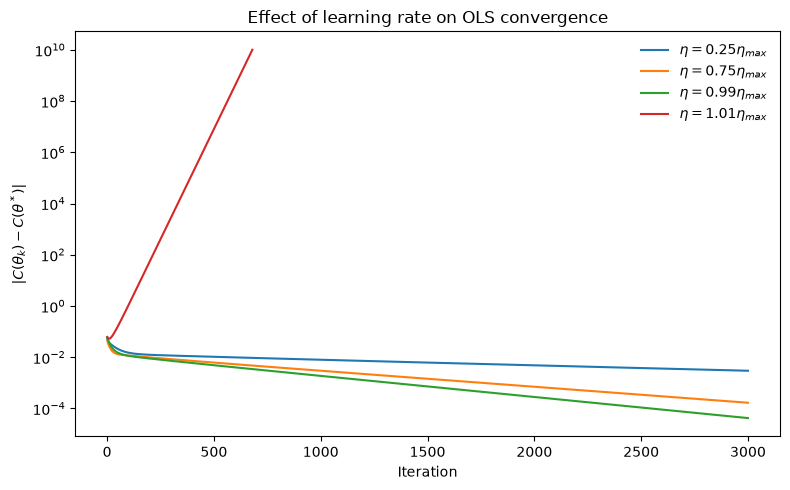

In [59]:
plt.figure(figsize=(8, 5))

for factor in eta_factors:

    costs = eta_results[factor]["cost"]

  
    cost_gap = np.abs(costs - closed_cost_ols)

    cost_gap = np.maximum(cost_gap, 1e-16)

    plt.semilogy(
        np.arange(1, len(cost_gap) + 1),
        cost_gap,
        label=fr"$\eta={factor:.2f}\eta_{{max}}$"
    )

plt.xlabel("Iteration")
plt.ylabel(r"$|C(\theta_k)-C(\theta^*)|$")
plt.title("Effect of learning rate on OLS convergence")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e4_learning_rate_cost.pdf", bbox_inches="tight")
plt.show()

In [60]:
print("\nFinal parameter errors:")

for factor in eta_factors:

    theta_eta = eta_results[factor]["theta"]

    error = np.linalg.norm(
        theta_eta - theta_ols_closed
    )

    print(
        f"{factor:.2f} eta_max : "
        f"||theta - theta_closed|| = {error:.6e}"
    )


Final parameter errors:
0.25 eta_max : ||theta - theta_closed|| = 1.269539e+00
0.75 eta_max : ||theta - theta_closed|| = 3.018245e-01
0.99 eta_max : ||theta - theta_closed|| = 1.514505e-01
1.01 eta_max : ||theta - theta_closed|| = 5.111492e+04


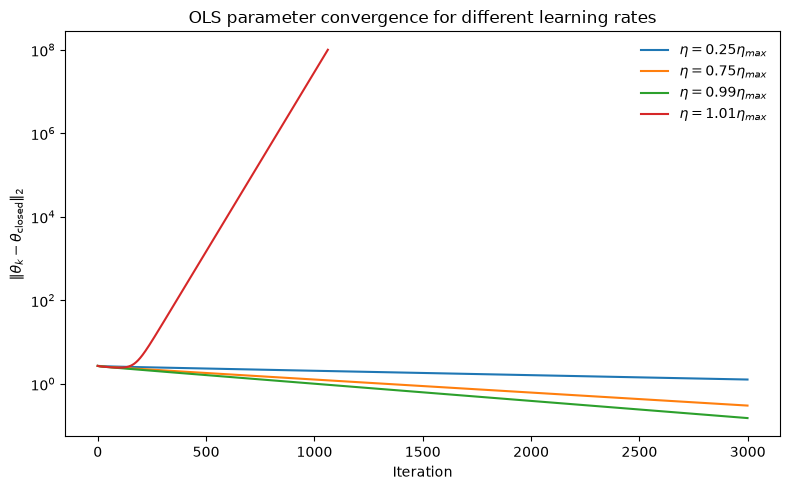

In [61]:
plt.figure(figsize=(8, 5))

for factor in eta_factors:

    eta_value = eta_results[factor]["eta"]

    theta = np.zeros_like(theta_ols_closed)

    error_history = []

    for k in range(3000):

        g = gradient_ols(
            theta,
            X_train_e,
            y_train_e
        )

        theta = theta - eta_value * g

        error = np.linalg.norm(
            theta - theta_ols_closed
        )

        error_history.append(error)

        if (not np.isfinite(error)) or error > 1e8:
            break

    plt.semilogy(
        error_history,
        label=fr"$\eta={factor:.2f}\eta_{{max}}$"
    )

plt.xlabel("Iteration")
plt.ylabel(
    r"$\|\theta_k-\theta_{\mathrm{closed}}\|_2$"
)
plt.title("OLS parameter convergence for different learning rates")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e4_learning_rate_theta.pdf", bbox_inches="tight")
plt.show()

## e.5 Gradient descent for Ridge

In [62]:
lam_ridge = 0.01

theta_ridge_closed = np.asarray(
    ridge(
        X_train_e,
        y_train_e,
        lam=lam_ridge
    )
).ravel()

print("Closed-form Ridge theta:")
print(theta_ridge_closed)

Closed-form Ridge theta:
[-0.0498 -0.5677  0.0766  0.3358 -0.041   0.0428]


In [63]:
p = X_train_e.shape[1]

H_ridge = (
    (2.0 / n_train) * X_train_e.T @ X_train_e
    + 2.0 * lam_ridge * np.eye(p)
)

ridge_eigenvalues = np.linalg.eigvalsh(H_ridge)

ridge_lambda_min = ridge_eigenvalues.min()
ridge_lambda_max = ridge_eigenvalues.max()

eta_max_ridge = 2.0 / ridge_lambda_max


eta_ridge = 0.5 * eta_max_ridge


print("Ridge lambda_min =", ridge_lambda_min)
print("Ridge lambda_max =", ridge_lambda_max)

print(
    "Ridge condition number =",
    ridge_lambda_max / ridge_lambda_min
)

print("Ridge eta_max =", eta_max_ridge)
print("eta used      =", eta_ridge)

Ridge lambda_min = 0.02368261778516762
Ridge lambda_max = 7.716475114645238
Ridge condition number = 325.82863873596153
Ridge eta_max = 0.2591856994658304
eta used      = 0.1295928497329152


In [64]:
def ridge_gradient_analytic(theta):

    return gradient_ridge(
        theta,
        X_train_e,
        y_train_e,
        lam_ridge
    )

In [65]:
def ridge_gradient_ad_function(theta):

    g = gradient_ridge_ad(
        jnp.asarray(theta),
        Xj,
        yj,
        lam_ridge
    )

    return np.asarray(g)

In [66]:
def ridge_cost_numpy(theta):

    residual = X_train_e @ theta - y_train_e

    return (
        np.mean(residual**2)
        + lam_ridge * np.sum(theta**2)
    )

In [67]:
def gradient_descent_ridge(
    theta0,
    gradient_function,
    eta,
    max_iter=20000,
    tol=1e-10
):

    theta = theta0.copy()

    cost_history = []

    for k in range(max_iter):

        gradient = np.asarray(
            gradient_function(theta)
        )

        theta = theta - eta * gradient

        cost = ridge_cost_numpy(theta)

        cost_history.append(cost)

        if np.linalg.norm(gradient) < tol:
            break

    return theta, np.array(cost_history), k + 1

In [68]:
theta0_ridge = np.zeros(X_train_e.shape[1])


theta_ridge_analytic, cost_ridge_analytic, n_iter_ridge_analytic = (
    gradient_descent_ridge(
        theta0=theta0_ridge,
        gradient_function=ridge_gradient_analytic,
        eta=eta_ridge,
        max_iter=20000,
        tol=1e-10
    )
)


theta_ridge_ad, cost_ridge_ad, n_iter_ridge_ad = (
    gradient_descent_ridge(
        theta0=theta0_ridge,
        gradient_function=ridge_gradient_ad_function,
        eta=eta_ridge,
        max_iter=20000,
        tol=1e-10
    )
)


print("Analytical Ridge iterations:", n_iter_ridge_analytic)
print("JAX Ridge iterations       :", n_iter_ridge_ad)

print("\nClosed-form Ridge theta:")
print(theta_ridge_closed)

print("\nGD Ridge theta:")
print(theta_ridge_analytic)

print(
    "\n||theta_GD analytical - theta_closed|| =",
    np.linalg.norm(theta_ridge_analytic - theta_ridge_closed)
)

print(
    "||theta_GD JAX - theta_closed||        =",
    np.linalg.norm(theta_ridge_ad - theta_ridge_closed)
)

Analytical Ridge iterations: 5980
JAX Ridge iterations       : 5980

Closed-form Ridge theta:
[-0.0498 -0.5677  0.0766  0.3358 -0.041   0.0428]

GD Ridge theta:
[-0.0498 -0.5677  0.0766  0.3358 -0.041   0.0428]

||theta_GD analytical - theta_closed|| = 4.207011039081796e-09
||theta_GD JAX - theta_closed||        = 4.207011592740148e-09


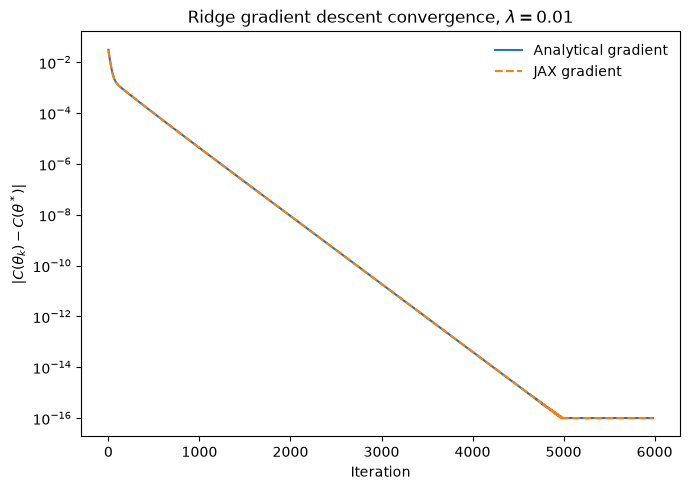

In [69]:
closed_cost_ridge = ridge_cost_numpy(theta_ridge_closed)

plt.figure(figsize=(7, 5))

plt.semilogy(
    np.arange(1, len(cost_ridge_analytic) + 1),
    np.maximum(np.abs(cost_ridge_analytic - closed_cost_ridge), 1e-16),
    label="Analytical gradient"
)

plt.semilogy(
    np.arange(1, len(cost_ridge_ad) + 1),
    np.maximum(np.abs(cost_ridge_ad - closed_cost_ridge), 1e-16),
    "--",
    label="JAX gradient"
)

plt.xlabel("Iteration")
plt.ylabel(r"$|C(\theta_k)-C(\theta^*)|$")
plt.title(fr"Ridge gradient descent convergence, $\lambda={lam_ridge}$")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e5_ridge_convergence.pdf", bbox_inches="tight")
plt.show()

---
# Part f) Momentum, AdaGrad, RMSprop and Adam

## F) momentum and adaptive learning.

**setup**

- Data from make_data, the degree should be chosen after e)
- Use the code from ex38 and tuesday37/38.




### f1
- Setting up all the methods, and the closed form, cost, gradient, hessian_eigs functions.
-  See if the methods converge to the closed form solotions for OLS and Ridge
- Plot : $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method. (ex38 2a)

In [70]:
#code from exerise38:
# setting up all the functions and methods


def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))


def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g                                 # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":    
        r = state.get("r", 0.0) + g * g                              # Eqs. (4.42) and (4.45)
        state["r"] = r 
        return theta - gamma * g /(np.sqrt(r) + eps ), state
    if method == "rmsprop":  
        r = rho * state.get("r", 0.0) + (1.0 - rho)*g*g                                # Eqs. (4.47) and (4.48)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":   
        m = beta1 * state.get("m", 0.0) + (1.0-beta1)*g
        r = beta2*state.get("r", 0.0) + (1.0-beta2)*g*g                                  # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m
        state["r"] = r 
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma*m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-12, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t



#Function from ex38 that fits to a specific RUNS list.
def runf1(X,y,theta_hat,lam,runs, num_iters=50000):
    grad = lambda th: gradient(th,X,y,lam)
    resultat = {}
    for method, gamma, color, label in runs:
        history, t = optimise(grad, np.zeros(X.shape[1]),method,gamma, num_iters = num_iters)
        distances = np.linalg.norm(history - theta_hat, axis = 1)
        resultat[(method,gamma)] = distances
    return resultat


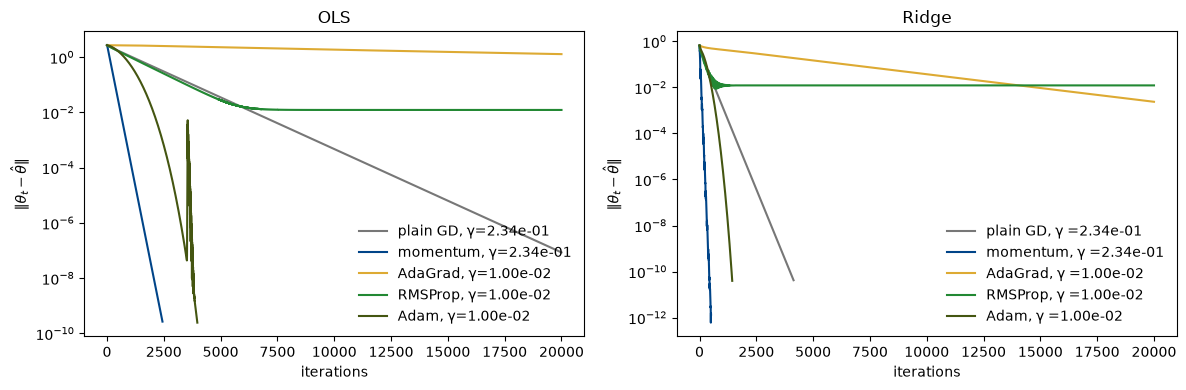

In [71]:
import jax
jax.config.update("jax_enable_x64", True)
#sceleton from week37tuesday


#----------------------
X_f , y_f = X_train_e , y_train_e 
eigf1 = hessian_eigs(X_f)
eigmin_f1 = eigf1[0]
eigmax_f1 = eigf1[-1]
gmaxf1 = 2 / eigmax_f1
#------------------------


#--------------------------
cf_OLS = closed_form(X_f,y_f)
cf_Ridge = closed_form(X_f,y_f, lam = lam_ridge) # same lambda as in e)
#--------------------------


#Setting up the Run list

RUN = (("plain", 0.9*gmaxf1 , "#777777", "plain GD"), ("momentum", 0.9*gmaxf1, "#004488", "momentum"),("adagrad", 0.01, "#DDAA33", "AdaGrad"), ("rmsprop", 0.01, "#228833", "RMSProp"),
       ("adam", 0.01, "#445511"  , "Adam"))

resultat_OLS = runf1(X_f,y_f,cf_OLS,0.0,RUN, num_iters = 20000)
resultat_Ridge = runf1(X_f, y_f, cf_Ridge, lam_ridge ,RUN, num_iters = 20000)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 4.0))
for method, gamma, color, label in RUN:
    ax1.semilogy(resultat_OLS[(method, gamma)], color=color, label=f"{label}, γ={gamma:.2e}")
    ax2.semilogy(resultat_Ridge[(method,gamma)], color = color, label=f"{label}, γ ={gamma:.2e}")
ax1.set_xlabel("iterations")
ax1.set_ylabel(r"$\|\theta_t - \hat\theta\|$")
ax1.set_title("OLS")
ax2.set_title("Ridge")
ax1.legend(loc="lower right", frameon=False, fontsize=10)
ax2.set_xlabel("iterations")
ax2.set_ylabel(r"$\|\theta_t - \hat\theta\|$")
ax2.legend(loc="lower right", frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("../results/f1_convergence.pdf", bbox_inches="tight")
plt.show()





**Setup**
 - Using runge_data function to (which includes make_data ) so that we get normalized and centered data. we use degree 6 here, could change after looking at e).
 - Setting up the runf1 function to go over a the RUN tuple. In the runf1 function we call on each of the methods from optimiser step, with a temporary lambda ( choose a specific after doing e) )
 - Comparing how each of the gradient optimisers compare to the closed_form solotuins, and seeing if they converge , ( the given tolerance is inside optimise function )
 - PlainGD and momentum use 0.9*gamma_max for the given degree 

 **Results**

 - momentum, Adam, PlainGD all converge, AdaGrad would also converge it would just need a lot more iterations, RMSProp will not converge.
 - Ridge causes faster convergence than OLS



## f2

- Mak a table that shows how long each method uses to converge, make it clear wether or not it is diverging or wether it doesnt converge within our given iterations.

LLM-assisted (Claude): the notebook versions were merged and the condition-number table computed with Claude

In [72]:
print("OLS")
for method, gamma, color, label in RUN:
    distanse = resultat_OLS[(method,gamma)]
    if (distanse < 1e-6).any():
        under = np.argmax(distanse < 1e-6)
        print(f"{label}_OLS converge, gamma = {gamma:.2e}: {under:.2e} iterations")
    else:
        print(f"{label}_OLS, gamma = {gamma}: does not converge")

print()
print("Ridge")
for method, gamma, color, label in RUN:
    distanse = resultat_Ridge[(method,gamma)]
    if (distanse < 1e-6).any():
        under = np.argmax(distanse < 1e-6)
        print(f"{label}_Ridge converge, gamma = {gamma:.2e}: {under:.2e} iterations")
    else:
        print(f"{label}_Ridge, gamma = {gamma:.2e}: does not converge")


OLS
plain GD_OLS converge, gamma = 2.34e-01: 1.71e+04 iterations
momentum_OLS converge, gamma = 2.34e-01: 1.57e+03 iterations
AdaGrad_OLS, gamma = 0.01: does not converge
RMSProp_OLS, gamma = 0.01: does not converge
Adam_OLS converge, gamma = 1.00e-02: 3.24e+03 iterations

Ridge
plain GD_Ridge converge, gamma = 2.34e-01: 2.32e+03 iterations
momentum_Ridge converge, gamma = 2.34e-01: 2.51e+02 iterations
AdaGrad_Ridge, gamma = 1.00e-02: does not converge
RMSProp_Ridge, gamma = 1.00e-02: does not converge
Adam_Ridge converge, gamma = 1.00e-02: 1.07e+03 iterations


## f3 

- Look at how the methods are dependent on the initial learning 

LLM-assisted (Claude): best-gamma selection partly written by Claude

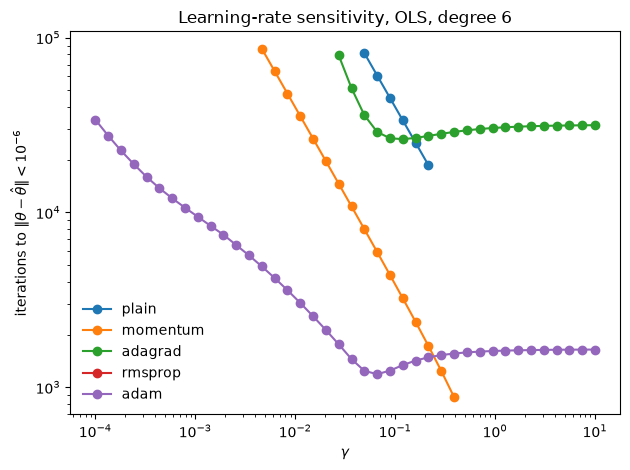

plain: best gamma = 0.215, iterations = 18611
momentum: best gamma = 0.389, iterations = 877
adagrad: best gamma = 0.119, iterations = 26233
rmsprop: never reaches tol = 1e-06
adam: best gamma = 0.0661, iterations = 1186


In [73]:
gammas = np.geomspace(1e-4, 10, 40)
modeller = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
theta0 = np.zeros(X_f.shape[1])
tol = 1e-6

skann = {}


with np.errstate(over="ignore", invalid="ignore"):              

    for method in modeller:
        iterasjoner = []
        for g in gammas:
            history, t = optimise(lambda th: gradient(th,X_f,y_f,lam=0), theta0, method ,g, num_iters = 100000)
            distanse = np.linalg.norm(history - cf_OLS, axis = 1 )
            if (distanse < tol).any():
                iterasjoner.append(np.argmax(distanse < tol))
            else:
                iterasjoner.append(np.nan)
            

        skann[method] = iterasjoner

fig, ax = plt.subplots()

for method in modeller:
    ax.loglog(gammas,skann[method],"o-" ,label = method)

ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"iterations to $\|\theta-\hat\theta\| < 10^{-6}$")
ax.set_title(r"Learning-rate sensitivity, OLS, degree 6")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/f3_gamma_scan.pdf", bbox_inches="tight")
plt.show()


#finding the best gamma for each method.

best_gamma = {}
for method in modeller:
    it = np.array(skann[method], dtype = float)
    if np.all(np.isnan(it)):
        best_gamma[method]= np.nan
        print(f"{method}: never reaches tol = {tol}")
    else:
        i = np.nanargmin(it)
        best_gamma[method] = gammas[i]
        print(f"{method}: best gamma = {gammas[i]:.3g}, iterations = {int(it[i])}")




---
# Part g) Lasso regression

## g.1 The subgradient of $|\theta|$ at zero

In [74]:
print("np.sign(0.0)            =", np.sign(0.0))
print("jax.grad(jnp.abs)(0.0)  =", float(jax.grad(jnp.abs)(0.0)))
print("jax.grad(jnp.abs)(-0.3) =", float(jax.grad(jnp.abs)(-0.3)))
print("jax.grad(jnp.abs)(0.3)  =", float(jax.grad(jnp.abs)(0.3)))

np.sign(0.0)            = 0.0
jax.grad(jnp.abs)(0.0)  = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0
jax.grad(jnp.abs)(0.3)  = 1.0


## g.2 Lasso by gradient descent

In [75]:
degree_g = 15

X_train_g = polynomial_features(x_train, degree_g)

X_mean_g = X_train_g.mean(axis=0)
X_std_g = X_train_g.std(axis=0)

X_train_g = (X_train_g - X_mean_g) / X_std_g

y_train_g = y_train - y_train.mean()

n_g = len(y_train_g)


def gradient_lasso(theta, X, y, lam):
    return (2.0 / len(y)) * X.T @ (X @ theta - y) + lam * np.sign(theta)


def gradient_descent_lasso(X, y, lam, eta, max_iter=50000):
    theta = np.zeros(X.shape[1])

    for k in range(max_iter):
        theta = theta - eta * gradient_lasso(theta, X, y, lam)

    return theta


H_g = (2.0 / n_g) * X_train_g.T @ X_train_g

eta_g = 0.5 * 2.0 / np.linalg.eigvalsh(H_g).max()

lam_g = 0.01

theta_lasso = gradient_descent_lasso(X_train_g, y_train_g, lam_g, eta_g)

print("eta =", eta_g)
print("Lasso theta:")
print(theta_lasso)

eta = 0.05254395376645446
Lasso theta:
[-0.0101 -0.5966  0.0009  0.417   0.0008  0.0007  0.0004  0.0002 -0.0001
 -0.0001  0.0006  0.0001  0.     -0.0139  0.0001]


## g.3 Benchmark against scikit-learn

In [76]:
from sklearn.linear_model import Lasso

for name, alpha in [("lam", lam_g), ("lam/2", lam_g / 2), ("lam/(2n)", lam_g / (2 * n_g))]:

    model = Lasso(alpha=alpha, fit_intercept=False, max_iter=200000)
    theta_sk = model.fit(X_train_g, y_train_g).coef_

    print(f"alpha = {name:<9} max |ours - sklearn| = {np.max(np.abs(theta_lasso - theta_sk)):.3e}")


theta_sklearn = Lasso(alpha=lam_g / 2, fit_intercept=False, max_iter=200000).fit(
    X_train_g, y_train_g
).coef_

print("\nours    exact zeros:", np.sum(theta_lasso == 0), "of", degree_g)
print("sklearn exact zeros:", np.sum(theta_sklearn == 0), "of", degree_g)
print("smallest |theta| from gradient descent:", np.min(np.abs(theta_lasso)))

alpha = lam       max |ours - sklearn| = 4.170e-01
alpha = lam/2     max |ours - sklearn| = 9.829e-04
alpha = lam/(2n)  max |ours - sklearn| = 7.840e+00

ours    exact zeros: 0 of 15
sklearn exact zeros: 11 of 15
smallest |theta| from gradient descent: 3.4303944125143584e-05


## g.4 Sparsity: Lasso against Ridge

coefficients below 1e-3:
  Lasso: 11 of 15
  Ridge: 0 of 15


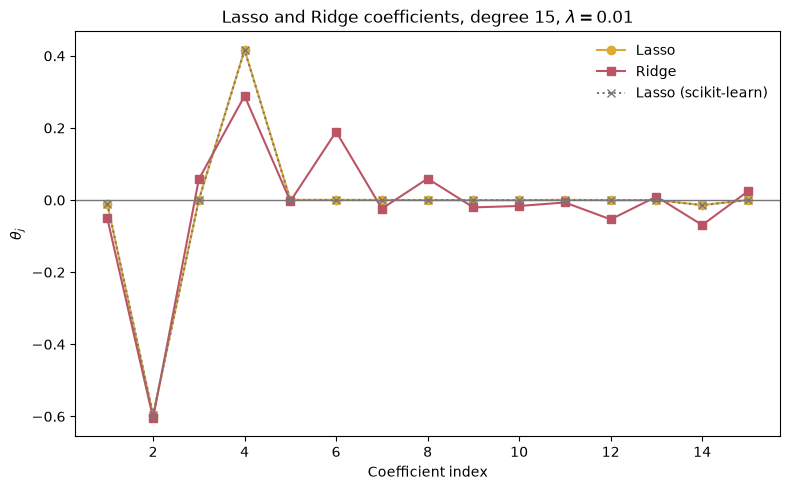

In [77]:
theta_ridge_g = np.asarray(ridge(X_train_g, y_train_g, lam=lam_g)).ravel()

print("coefficients below 1e-3:")
print("  Lasso:", np.sum(np.abs(theta_lasso) < 1e-3), "of", degree_g)
print("  Ridge:", np.sum(np.abs(theta_ridge_g) < 1e-3), "of", degree_g)


j = np.arange(1, degree_g + 1)

plt.figure(figsize=(8, 5))

plt.plot(j, theta_lasso, "o-", color=YELLOW, label="Lasso")
plt.plot(j, theta_ridge_g, "s-", color=RED, label="Ridge")
plt.plot(j, theta_sklearn, "x:", color=GREY, label="Lasso (scikit-learn)")

plt.axhline(0, color=GREY, linewidth=1)
plt.xlabel("Coefficient index")
plt.ylabel(r"$\theta_j$")
plt.title(fr"Lasso and Ridge coefficients, degree {degree_g}, $\lambda={lam_g}$")
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("../results/g4_lasso_vs_ridge.pdf", bbox_inches="tight")
plt.show()

---
# Part h) Stochastic gradient descent

## h.1 Mini-batches and epochs

In [78]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026,theta0 = None ,**kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype = float)
    state, t, history = {}, 0 , [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)                                  # the gradient of the cost on this minibatch
            gamma_t = gamma if schedule is None else step_length(t, *schedule)                            # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

## h.2 Dependence on batch size and number of epochs

LLM-assisted (Claude): parts of these cells written by Claude; verified by the author.

gamma_full = 0.260, gamma_one = 0.016, gamma = 0.130
 flops per epoch ~ 2np = 960 (independent of M)


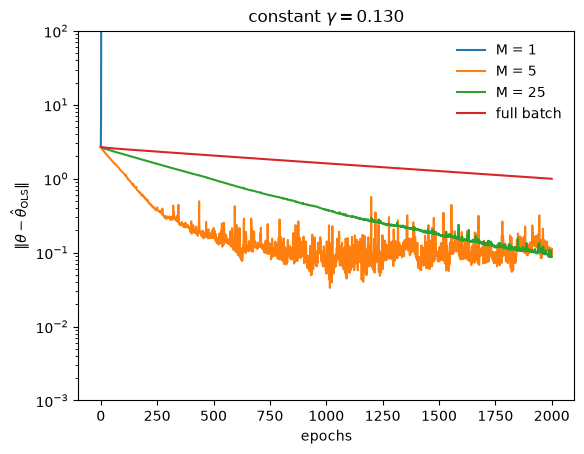

In [79]:

n = len(y_f)

n_epochs = 2000

epochs = np.arange(n_epochs + 1) 

gamma_full = 2 / hessian_eigs(X_f).max()
gamma_one = 2 / (2*np.sum(X_f**2,axis=1)).max()
gamma = 0.5 * gamma_full         # choose: below gamma_full, above gamma_one

print(f"gamma_full = {gamma_full:.3f}, gamma_one = {gamma_one:.3f}, gamma = {gamma:.3f}")
print(f" flops per epoch ~ 2np = {2*n*X_f.shape[1]} (independent of M)")

C_min = cost(cf_OLS, X_f, y_f)
t1 = 50
t0 = gamma * t1

runs = [(dict(batch_size = 1), "M = 1"),
        (dict(batch_size = 5), "M = 5"),
        (dict(batch_size = 25), "M = 25"),
        (dict(batch_size = n), "full batch")]

fig, ax = plt.subplots()
with np.errstate(over = "ignore", invalid = "ignore"):
    for kwargs, label in runs:
        history = sgd(X_f,y_f, n_epochs = n_epochs, **kwargs, gamma = gamma)
        distanse = np.linalg.norm(history - cf_OLS, axis = 1 )
        ax.semilogy(epochs,distanse,label = label)


ax.set_ylim(1e-3,1e2)

ax.set_xlabel("epochs")
ax.set_ylabel(r"$\|\theta - \hat\theta_{\mathrm{OLS}}\|$")
ax.set_title(fr"constant $\gamma = {gamma:.3f}$")
ax.legend(frameon = False)
plt.savefig("../results/h2_sgd_batch_size.pdf", bbox_inches="tight")
plt.show()





## h.3 Learning rate schedule

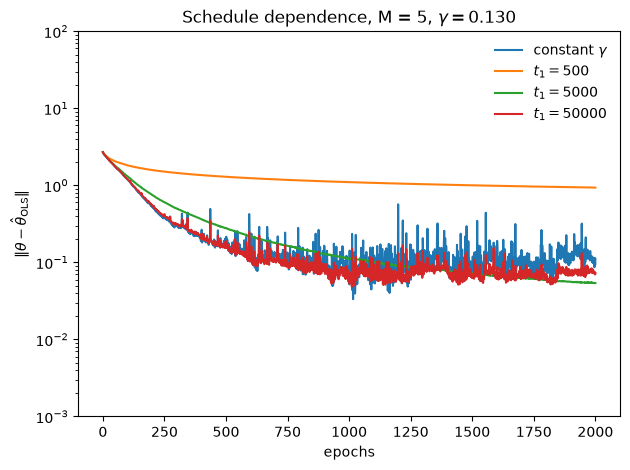

In [80]:
#from ex38

runs2 = [(dict(batch_size=5), r"constant $\gamma$"),
        (dict(batch_size=5, schedule=(gamma*500, 500)), r"$t_1 = 500$"),
        (dict(batch_size=5, schedule=(gamma*5000, 5000)), r"$t_1 = 5000$"),
        (dict(batch_size=5, schedule=(gamma*50000, 50000)), r"$t_1 = 50000$")]

fig, ax = plt.subplots()

for kwargs, label in runs2:
    history = sgd(X_f,y_f, n_epochs = n_epochs, **kwargs, gamma = gamma)
    distanse = np.linalg.norm(history - cf_OLS, axis = 1 )

    ax.semilogy(epochs,distanse,label = label)

ax.set_ylabel(r"$\|\theta - \hat\theta_{\mathrm{OLS}}\|$")
ax.set_xlabel("epochs")
ax.set_title(fr"Schedule dependence, M = 5, $\gamma = {gamma:.3f}$")
ax.set_ylim(1e-3, 1e2)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/h3_sgd_schedule.pdf", bbox_inches="tight")
plt.show()



## h.4 SGD against full-batch gradient descent

LLM-assisted (Claude): parts of these cells written by Claude; verified by the author.

In [81]:
#Use the best gammas for each method from f3, 

sgd_gamma = {}
for method in modeller:
    if np.isnan(best_gamma[method]):
        sgd_gamma[method] = 0.01 #set RMSProp gamma = 0.01 since it didnt converge and never found a best gamma for it
    else:
        sgd_gamma[method] = min(best_gamma[method], 0.5 * gamma_full)

with np.errstate(over = "ignore", invalid = "ignore"):
    for method in modeller:
        history = sgd(X_f,y_f,method = method, n_epochs = n_epochs, batch_size = 5, gamma = sgd_gamma[method])
        distanse = np.linalg.norm(history - cf_OLS, axis = 1 )
        print(f"{method}: gamma = {sgd_gamma[method]:.3g}, distance after {n_epochs}, epochs = {distanse[-1]:.2e}")

plain: gamma = 0.13, distance after 2000, epochs = 1.11e-01


momentum: gamma = 0.13, distance after 2000, epochs = nan


adagrad: gamma = 0.119, distance after 2000, epochs = 8.25e-01


rmsprop: gamma = 0.01, distance after 2000, epochs = 5.53e-02


adam: gamma = 0.0661, distance after 2000, epochs = 1.76e-01


---
# Part i) Final comparison: OLS, Ridge and Lasso with cross-validation

LLM-assisted (Claude): cross-validation setup, convergence check, i.2–i.5 cells and the i.5 figure code written with Claude from the author's draft

## i.1 Setup

Same setup for all three methods

In [82]:
import warnings
from sklearn.exceptions import ConvergenceWarning


kfold = KFold(n_splits=10, shuffle=True, random_state=2026)

nlambda_l = 30
nlambda_r = 100
degrees = np.arange(1,16)
lambdas_l = np.logspace(-6, 0, nlambda_l)
lambdas_r = np.logspace(-8,2, nlambda_r)

n_fold = len(x_train) * (kfold.get_n_splits() -1 ) // kfold.get_n_splits() #samme konvensjon som i d2.

#functions from week36tuesday notebook.
def cv_curve(make_model, alphas, x, y, cv):
    """Mean and standard error over folds of the CV-MSE, for every alpha."""
    mean, se = np.zeros(len(alphas)), np.zeros(len(alphas))
    for i, a in enumerate(alphas):
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always", ConvergenceWarning)

            scores = -cross_val_score(make_model(a), x[:, np.newaxis], y, cv=cv,scoring="neg_mean_squared_error")
        if any(issubclass(warn.category, ConvergenceWarning) for warn in w):
            mean[i], se[i] = np.inf, np.inf
        else:
                                                                
            mean[i], se[i] = scores.mean(), scores.std(ddof=1) / np.sqrt(len(scores))
    return mean, se

def select(alphas, mean, se):
    """The minimum-CV alpha, and the largest alpha within one standard error of it."""
    i = np.argmin(mean)
    return alphas[i], alphas[mean <= mean[i] + se[i]].max()


lasso_model = lambda deg, lam: make_pipeline(PolynomialFeatures(degree=deg, include_bias=False),
                                           StandardScaler(),
                                           Lasso(alpha= lam / 2, max_iter=100000))

ridge_model = lambda deg, lam: make_pipeline(PolynomialFeatures(degree=deg, include_bias = False), StandardScaler(),
                                      Ridge(alpha= n_fold * lam))

ols_model = lambda deg: make_pipeline(PolynomialFeatures(degree=deg, include_bias = False), StandardScaler(), LinearRegression())
# Make a loop over degrees and lambda values, 




## i2 Cross-val MSE for OLS, Ridge and Lasso

k = 10, all three methods use the same 80 data points with the same folds, only on the training data.

The lambda grids are different for Ridge and Lasso because of the way it is used as a straffeledd.

n_fold * lambda is used to be the same as in d) see explenation from there.
and lam / 2 is used to be the same as in g )

Lasso fits that did not converge in any fold are discarded. For each point we
store the mean CV-MSE and its standard error, which is used in i.3.

In [83]:
mean_l = np.zeros((len(degrees), len(lambdas_l)))
se_l = np.zeros ((len(degrees), len(lambdas_l)))


for i, deg in enumerate(degrees):
    mean_l[i], se_l[i] = cv_curve(lambda lam: lasso_model(deg,lam), lambdas_l, x_train, y_train, kfold)


print("Lasso")
i_best, j_best = np.unravel_index(np.argmin(mean_l), mean_l.shape)
print("beste grad:", degrees[i_best])
print("beste lambda:", lambdas_l[j_best])
print("CV-MSE:", mean_l[i_best, j_best], "+-", se_l[i_best, j_best])

Lasso
beste grad: 8
beste lambda: 0.0003039195382313198
CV-MSE: 0.02499721283741065 +- 0.0048037805476562005


In [84]:
mean_r = np.zeros((len(degrees), len(lambdas_r)))
se_r = np.zeros((len(degrees), len(lambdas_r)))

for i, deg in enumerate(degrees):
    mean_r[i], se_r[i] = cv_curve(lambda lam: ridge_model(deg,lam), lambdas_r, x_train, y_train, kfold)


print("Ridge")
i_best, j_best = np.unravel_index(np.argmin(mean_r), mean_r.shape)
print("beste grad:", degrees[i_best])
print("beste lam:", lambdas_r[j_best])
print("CV-MSE:", mean_r[i_best, j_best], "+-", se_r[i_best, j_best])


Ridge
beste grad: 10
beste lam: 6.579332246575682e-07
CV-MSE: 0.018932966663456657 +- 0.0036174927478055618


In [85]:
mean_ols = np.zeros(len(degrees))
se_ols   = np.zeros(len(degrees))

for i, deg in enumerate(degrees):
    m, s = cv_curve(lambda a: ols_model(deg), [0], x_train, y_train, kfold)
    mean_ols[i], se_ols[i] = m[0], s[0]

i_best = np.argmin(mean_ols)
print("OLS: beste grad:", degrees[i_best],
      " CV-MSE:", mean_ols[i_best], "+-", se_ols[i_best])

OLS: beste grad: 10  CV-MSE: 0.02508168144984258 +- 0.005748239459247936


## i.3 Model selection

For each method we select the model with the lowest cross-validated MSE
(mean over the 10 folds), and report it together with its standard error.


In [86]:
import pandas as pd


# find best index for each method:

i_ols = np.argmin(mean_ols)

i_ridge, j_ridge = np.unravel_index(np.argmin(mean_r), mean_r.shape )

i_lasso, j_lasso = np.unravel_index(np.argmin(mean_l), mean_l.shape )

best = pd.DataFrame({
    "method": ["OLS", "Ridge", "Lasso"],
    "degree": [degrees[i_ols], degrees[i_ridge], degrees[i_lasso] ],
    "lambda": [np.nan, lambdas_r[j_ridge], lambdas_l[j_lasso] ],
    "CV_MSE": [mean_ols[i_ols] , mean_r[i_ridge, j_ridge], mean_l[i_lasso,j_lasso]],
    "SE": [se_ols[i_ols], se_r[i_ridge,j_ridge], se_l[i_lasso,j_lasso]] })

print(best.to_string(index=False, float_format="%.3g"))

#ons-SE- rule (section3.15)
print()

grense = mean_ols[i_ols] + se_ols[i_ols]
i_ols_1se = np.argmax(mean_ols <= grense)
print(f"OLS one-SE rule: threshold = {grense:.3g}, "
      f"degree = {degrees[i_ols_1se]}, CV_MSE = {mean_ols[i_ols_1se]:.3g} +- {se_ols[i_ols_1se]:.3g}")


method  degree   lambda  CV_MSE      SE
   OLS      10      NaN  0.0251 0.00575
 Ridge      10 6.58e-07  0.0189 0.00362
 Lasso       8 0.000304   0.025  0.0048

OLS one-SE rule: threshold = 0.0308, degree = 10, CV_MSE = 0.0251 +- 0.00575


## i.4 Bias–variance decomposition of the selected models

To test which term of the bias–variance decomposition each method reduces, we
repeat the bootstrap analysis of part c (100 resamples of the training data,
evaluated on the test set) for the selected models. Each penalised model is
compared with OLS at the same degree, so that the difference shows the effect
of the penalty alone:

- OLS (degree 10) vs Ridge (degree 10, λ from i.3)
- OLS (degree 8) vs Lasso (degree 8, λ from i.3)

As in part c, the bias² term is computed against the noisy test targets and
therefore includes σ².

In [87]:
# using same bias variance sweep as in c) with some small alterations.

def bias_variance_sweep2(n=100, sigma=0.1, degrees=degrees_c, n_bootstraps=100, seed=2026, lam = 0.0, make_model = None ):
    x, y = make_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
    y_test_col = y_test.reshape(-1, 1)

    error, bias, variance = (np.zeros(len(degrees)) for _ in range(3))

    for i, degree in enumerate(degrees):
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for b in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train, random_state=seed + b)
            if make_model is None:
                y_pred[:, b] = fit_predict(x_, x_test, y_, degree, lam = lam)[1]
            else:
                y_pred[:,b] = make_model().fit(x_[:,None],y_).predict(x_test[:,None])

        error[i] = np.mean(np.mean((y_test_col - y_pred)**2, axis=1, keepdims=True))
        bias[i] = np.mean((y_test_col - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[i] = np.mean(np.var(y_pred, axis=1, keepdims=True))
        
    return error, bias, variance


methods = {
    "OLS, deg 10": dict(degrees=[10]),
    "Ridge, deg 10": dict(degrees=[10], lam = lambdas_r[j_ridge]),
    "OLS, deg 8": dict(degrees=[8]),
    "Lasso, deg 8": dict(degrees=[8], make_model = lambda: lasso_model(8,lambdas_l[j_lasso]))
}

rader = []

for name, kw in methods.items():
    err, b2, var = bias_variance_sweep2(**kw)
    rader.append({"model": name, "error": err[0], "bias2": b2[0], "variance": var[0]})

bv = pd.DataFrame(rader)

print(bv.to_string(index=False, float_format="%.3g"))

        
    

/tmp/claude-1000/-home-litech/ca846f27-3496-4646-9a7e-2ea1c88cb9be/scratchpad/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.229152e-03, tolerance: 9.001e-04
  model = cd_fast.enet_coordinate_descent(
/tmp/claude-1000/-home-litech/ca846f27-3496-4646-9a7e-2ea1c88cb9be/scratchpad/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.201245e-03, tolerance: 8.632e-04
  model = cd_fast.enet_coordinate_descent(


        model  error  bias2  variance
  OLS, deg 10   8.77 0.0778       8.7
Ridge, deg 10   3.28  0.317      2.97
   OLS, deg 8  0.378  0.111     0.267
 Lasso, deg 8 0.0889 0.0171    0.0717


## i5 CV-MSE against degrees for all three methods, with the SE as errorbars

For Ridge and Lasso we choose the best lambda for each degree.

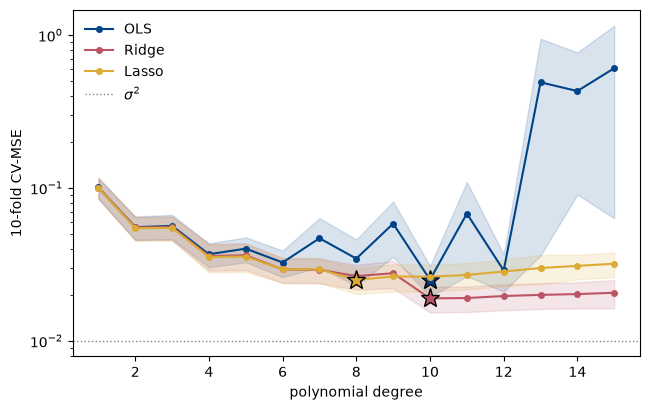

In [88]:
rows = np.arange(len(degrees))
j_r_deg = np.argmin(mean_r, axis=1)            # best lambda for each degree
j_l_deg = np.argmin(mean_l, axis=1)

curves = {
    "OLS":   (mean_ols,               se_ols,               BLUE,   i_ols),
    "Ridge": (mean_r[rows, j_r_deg],  se_r[rows, j_r_deg],  RED,   i_ridge),
    "Lasso": (mean_l[rows, j_l_deg],  se_l[rows, j_l_deg],  YELLOW,    i_lasso),
}

fig, ax = plt.subplots(figsize=(6.6, 4.2))
for name, (m, s, c, i_sel) in curves.items():
    ok = np.isfinite(m)                         # skip degrees where no Lasso fit converged
    ax.plot(degrees[ok], m[ok], "o-", color=c, ms=4, label=name)
    ax.fill_between(degrees[ok], (m - s)[ok], (m + s)[ok], color=c, alpha=0.15)
    ax.plot(degrees[i_sel], m[i_sel], "*", color=c, ms=14, mec="k")

ax.axhline(0.1**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("10-fold CV-MSE")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/i5_cv_comparison.pdf", bbox_inches="tight")
plt.show()

---
# Extra checks for the report


> **LLM note:** the cells below were written with Claude Code (Claude Opus 5.5, October 2026), code level 2. Checked by the author.


## Bias against the true f, and the median error, for the selected models


In [89]:
def bias_vs_truth(degree, lam=0.0, make_model=None, B=100, seed=2026):
    x, y = make_data(n=100, sigma=0.1, seed=seed)
    x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=seed)
    P = np.empty((len(x_te), B))

    for b in range(B):
        xa, ya = resample(x_tr, y_tr, random_state=seed + b)
        if make_model is None:
            P[:, b] = fit_predict(xa, x_te, ya, degree, lam=lam)[1]
        else:
            P[:, b] = make_model().fit(xa[:, None], ya).predict(x_te[:, None])

    f_te = runge(x_te)
    return {"bias2_y": np.mean((y_te - P.mean(axis=1))**2),
            "bias2_f": np.mean((f_te - P.mean(axis=1))**2),
            "median_abs_error": np.median(np.abs(P - f_te[:, None]))}


with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    rader = []
    for name, kw in {"OLS, deg 10": dict(degree=10),
                     "Ridge, deg 10": dict(degree=10, lam=lambdas_r[j_ridge]),
                     "OLS, deg 8": dict(degree=8),
                     "Lasso, deg 8": dict(degree=8, make_model=lambda: lasso_model(8, lambdas_l[j_lasso]))}.items():
        rader.append({"model": name, **bias_vs_truth(**kw)})

print(pd.DataFrame(rader).to_string(index=False, float_format="%.3g"))


        model  bias2_y  bias2_f  median_abs_error
  OLS, deg 10   0.0778   0.0556            0.0635
Ridge, deg 10    0.317    0.283            0.0554
   OLS, deg 8    0.111   0.0894            0.0573
 Lasso, deg 8   0.0171  0.00486             0.054


## Lasso fits that were skipped in i.2 because they did not converge


In [90]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for i, deg in enumerate(degrees):
        skipped = ~np.isfinite(mean_l[i])
        kept_best = np.min(mean_l[i][~skipped])

        if skipped.any():
            mse_skipped = [(-cross_val_score(lasso_model(deg, lam), x_train[:, None], y_train,
                                             cv=kfold, scoring="neg_mean_squared_error")).mean()
                           for lam in lambdas_l[skipped]]
            print(f"degree {deg:2d}: skipped {skipped.sum():2d} of {len(lambdas_l)}, "
                  f"best kept {kept_best:.4f}, best skipped {min(mse_skipped):.4f}")
        else:
            print(f"degree {deg:2d}: skipped  0 of {len(lambdas_l)}, best kept {kept_best:.4f}")


degree  1: skipped  0 of 30, best kept 0.1004
degree  2: skipped  0 of 30, best kept 0.0545
degree  3: skipped  0 of 30, best kept 0.0547
degree  4: skipped  0 of 30, best kept 0.0353
degree  5: skipped  0 of 30, best kept 0.0355
degree  6: skipped  0 of 30, best kept 0.0293
degree  7: skipped  0 of 30, best kept 0.0293
degree  8: skipped  0 of 30, best kept 0.0250


degree  9: skipped 11 of 30, best kept 0.0263, best skipped 0.0317


degree 10: skipped 11 of 30, best kept 0.0262, best skipped 0.0354


degree 11: skipped 11 of 30, best kept 0.0269, best skipped 0.0435


degree 12: skipped 12 of 30, best kept 0.0283, best skipped 0.0200


degree 13: skipped 12 of 30, best kept 0.0299, best skipped 0.0195


degree 14: skipped 11 of 30, best kept 0.0309, best skipped 0.0199


degree 15: skipped 13 of 30, best kept 0.0319, best skipped 0.0199


## Curvature of single minibatches (M = 5, degree 6)


In [91]:
rng = np.random.default_rng(2026)

lam_batch = np.array([hessian_eigs(X_f[idx]).max()
                      for idx in (rng.choice(len(y_f), 5, replace=False) for _ in range(2000))])

print(f"full-batch lambda_max = {hessian_eigs(X_f).max():.2f}")
print(f"minibatch lambda_max: median {np.median(lam_batch):.2f}, max {lam_batch.max():.1f}")
print(f"fraction of minibatches where gamma = 0.13 > 2/lambda_max: {np.mean(0.13 > 2 / lam_batch):.2f}")


full-batch lambda_max = 7.70
minibatch lambda_max: median 7.40, max 50.6
fraction of minibatches where gamma = 0.13 > 2/lambda_max: 0.22
